# Market Risk Prediction System - Multi-Asset ML Pipeline

---

**Author:** Michael Chukwudi  
**Date:** 2026  
**Repository:** [https://github.com/mikechuksanalyst/market-risk-prediction](https://github.com)

---

## Overview

This notebook implements a fully reproducible, end-to-end machine learning pipeline for binary classification of market risk regimes. Using daily price data from **Bitcoin (BTC), S&P 500, Gold, and the VIX** spanning **January 2017 to February 2026**, the system predicts whether next-day Bitcoin volatility will enter a *high-risk* or *low-risk* state.

The pipeline is built around professional financial ML standards:

- **No data leakage**: all thresholds and statistics use only past information at each point in time
- **Time-series aware cross-validation**: no random shuffling of temporal data at any stage
- **Baseline benchmarking**: every ML model is compared against a naive persistence baseline
- **Class-balanced training**: models stay robust to shifting class distributions
- **Correct statistical inference**: Diebold-Mariano test for dependent time-series forecasts
- **Permutation importance**: bias-corrected feature attribution instead of MDI-only
- **Walk-forward validation**: rolling retraining windows for out-of-time stability assessment
- **Deterministic**: fixed seeds ensure identical results on every run

---

## Pipeline

| Step | Description |
|------|-------------|
| 0 | **Environment Setup**: imports, config, logging, output directories |
| 1 | **Data Ingestion**: download multi-asset time series via `yfinance` |
| 2 | **Preprocessing**: business-day alignment, forward-fill, NaN removal |
| 3 | **Feature Engineering**: returns, rolling volatility, momentum, lags, cross-asset ratios |
| 4 | **Train / Test Split**: strict chronological 80/20 split, no shuffling |
| 5 | **Modeling**: Logistic Regression, Ridge Classifier (calibrated), Random Forest |
| 6 | **Evaluation**: Accuracy, Precision, Recall, F1, ROC-AUC vs. baseline |
| 7 | **Statistical Tests**: Diebold-Mariano test (correct for dependent series) |
| 8 | **Feature Attribution**: MDI importances + permutation importance for bias check |
| 9 | **Walk-Forward Validation**: rolling retraining for temporal stability |
| 10 | **Trading Simulation**: equity curves with risk-adjusted baseline |
| 11 | **Visualisations**: 12 publication-quality figures saved to disk |
| 12 | **Results Export**: all metrics to TXT and Excel, README-ready |


---
## Step 0: Environment Setup and Global Configuration

All parameters live here. Changing one value here reruns the whole pipeline with that setting.  
`RANDOM_SEED` is applied to every stochastic component to guarantee reproducibility.

In [14]:
import os
import warnings
import random
import logging
import json
from pathlib import Path
from datetime import datetime
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf

from scipy import stats
from scipy.stats import norm

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss,
)

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Date Range
START_DATE = "2017-01-01"
END_DATE   = "2026-02-20"

# Asset Universe
TICKERS = {
    "BTC"  : "BTC-USD",
    "SP500": "^GSPC",
    "GOLD" : "GC=F",
    "VIX"  : "^VIX",
}

# Feature Windows
SHORT_WINDOW      = 7
LONG_WINDOW       = 30
VOLATILITY_WINDOW = 7

# Model / CV
N_SPLITS        = 5
WALK_FWD_SPLITS = 8    # number of walk-forward windows

# Output Directories
OUTPUT_DIR  = Path("results")
FIGURES_DIR = OUTPUT_DIR / "figures"
DATA_DIR    = Path("data")

for _dir in [OUTPUT_DIR, FIGURES_DIR, DATA_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

print(f"Environment ready.  Seed={RANDOM_SEED}  |  {START_DATE} to {END_DATE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Environment ready.  Seed=42  |  2017-01-01 to 2026-02-20
Output directory: C:\Users\User\Downloads\MYPROJECTS\results


In [15]:
# Plotting style -- dark GitHub-inspired theme
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "#0d1117",
    "axes.facecolor"   : "#161b22",
    "axes.edgecolor"   : "#30363d",
    "axes.labelcolor"  : "#c9d1d9",
    "axes.titlecolor"  : "#f0f6fc",
    "axes.grid"        : True,
    "grid.color"       : "#21262d",
    "grid.linewidth"   : 0.8,
    "xtick.color"      : "#8b949e",
    "ytick.color"      : "#8b949e",
    "text.color"       : "#c9d1d9",
    "legend.facecolor" : "#161b22",
    "legend.edgecolor" : "#30363d",
    "font.family"      : "monospace",
})

PALETTE = {
    "btc"     : "#f7931a",
    "sp500"   : "#4c9be8",
    "gold"    : "#ffd700",
    "vix"     : "#e06c75",
    "pos"     : "#56d364",
    "neg"     : "#e06c75",
    "accent"  : "#58a6ff",
    "muted"   : "#8b949e",
    "baseline": "#a371f7",
}

def _save(fig: plt.Figure, filename: str) -> None:
    """Save figure to the figures directory and display inline."""
    path = FIGURES_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor=fig.get_facecolor())
    log.info(f"  Saved figure: {path}")

print("Plot style configured.")

Plot style configured.


---
## Step 1: Data Ingestion

Adjusted closing prices are downloaded for all four assets via `yfinance`. Each series is fetched individually, timezone-naive, then joined into a single aligned DataFrame. Raw data is persisted to `data/raw_prices.csv` for audit purposes.

**Assets:**
- `BTC-USD`: Bitcoin, trades 24/7 including weekends
- `^GSPC`: S&P 500 US equity benchmark, weekdays only
- `GC=F`: Gold front-month futures, weekdays with occasional early closes
- `^VIX`: CBOE Volatility Index derived from SPX options, weekdays only

In [16]:
def download_data(tickers: dict, start: str, end: str) -> pd.DataFrame:
    """
    Download adjusted closing prices for each asset via yfinance.

    Parameters
    ----------
    tickers : dict  {name: ticker_symbol}
    start   : str   ISO date string
    end     : str   ISO date string

    Returns
    -------
    pd.DataFrame
        One column per asset, DatetimeIndex (timezone-naive).
    """
    log.info("=" * 70)
    log.info("STEP 1 - DATA INGESTION")
    log.info("=" * 70)

    frames = {}
    for name, ticker in tickers.items():
        log.info(f"  Downloading {name:6s} ({ticker}) ...")
        raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)

        if raw.empty:
            raise ValueError(
                f"No data returned for {ticker}. "
                "Check your internet connection or ticker symbol."
            )

        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)

        series = raw["Close"].copy()
        series.index = pd.to_datetime(series.index).tz_localize(None)
        frames[name] = series

        log.info(
            f"    {len(series):>4,} rows  |  "
            f"{series.index[0].date()} to {series.index[-1].date()}"
        )

    prices = pd.DataFrame(frames)
    prices.dropna(how="all", inplace=True)

    log.info(f"\n  Combined dataset : {prices.shape[0]:,} rows x {prices.shape[1]} assets")
    log.info(f"  Date range       : {prices.index[0].date()} to {prices.index[-1].date()}")

    prices.to_csv(DATA_DIR / "raw_prices.csv")
    log.info(f"  Persisted raw prices to {DATA_DIR / 'raw_prices.csv'}")

    return prices


prices_raw = download_data(TICKERS, START_DATE, END_DATE)
prices_raw.tail(5)

14:48:09  INFO      ======================================================================
14:48:09  INFO      STEP 1 - DATA INGESTION
14:48:09  INFO      ======================================================================
14:48:09  INFO        Downloading BTC    (BTC-USD) ...
14:48:09  INFO          3,337 rows  |  2017-01-01 to 2026-02-19
14:48:09  INFO        Downloading SP500  (^GSPC) ...
14:48:09  INFO          2,295 rows  |  2017-01-03 to 2026-02-19
14:48:09  INFO        Downloading GOLD   (GC=F) ...
14:48:09  INFO          2,296 rows  |  2017-01-03 to 2026-02-19
14:48:09  INFO        Downloading VIX    (^VIX) ...
14:48:09  INFO          2,295 rows  |  2017-01-03 to 2026-02-19
14:48:09  INFO      
  Combined dataset : 3,337 rows x 4 assets
14:48:09  INFO        Date range       : 2017-01-01 to 2026-02-19
14:48:09  INFO        Persisted raw prices to data\raw_prices.csv


,BTC,SP500,GOLD,VIX
Date,,,,
2026-02-15,68788.187500,NaN,NaN,NaN
2026-02-16,68843.156250,NaN,NaN,NaN
2026-02-17,67494.218750,6843.220215,4882.899902,20.290001
2026-02-18,66425.320312,6881.310059,4986.500000,19.620001
2026-02-19,66957.523438,6861.890137,4975.899902,20.230000


---
## Step 2: Data Preprocessing

**Key steps:**

1. **Business-day alignment** -- `asfreq("B")` reindexes to the Mon-Fri calendar, inserting explicit NaN rows for any missing dates. This is critical because BTC trades seven days a week while equity markets close on weekends and public holidays. Without this step, the index is irregular and rolling statistics silently span the wrong calendar periods.

2. **Forward-fill (max 3 days)** -- Short gaps in VIX, Gold, and SP500 are filled by carrying the last known value forward. The `limit=3` cap prevents propagating stale data across longer outages.

3. **Drop residual NaNs** -- Any rows that cannot be filled are dropped entirely.

In [17]:
def preprocess(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Align to business-day calendar, forward-fill short gaps, drop residual NaNs.

    Parameters
    ----------
    prices : pd.DataFrame  Raw price DataFrame from download_data().

    Returns
    -------
    pd.DataFrame  Clean, business-day aligned price DataFrame.
    """
    log.info("\n" + "=" * 70)
    log.info("STEP 2 - DATA PREPROCESSING")
    log.info("=" * 70)

    log.info(f"  Input  shape : {prices.shape}")
    missing_before = prices.isna().sum()
    log.info(f"  Missing values before fill:\n{missing_before.to_string()}")

    # Align to Mon-Fri business-day calendar.
    # This inserts explicit NaN rows for non-trading days, making
    # the time index regular so rolling calculations are correct.
    prices = prices.asfreq("B")
    log.info(f"  After asfreq('B') : {prices.shape[0]:,} rows")

    prices = prices.ffill(limit=3)
    prices.dropna(inplace=True)

    log.info(f"  Output shape : {prices.shape}")
    log.info(f"  Remaining NaN cells : {prices.isna().sum().sum()}")

    return prices


prices = preprocess(prices_raw)
print(f"\nClean price data: {prices.shape[0]:,} rows from {prices.index[0].date()} to {prices.index[-1].date()}")
prices.describe().round(2)

14:48:09  INFO      
14:48:09  INFO      STEP 2 - DATA PREPROCESSING
14:48:09  INFO      ======================================================================
14:48:09  INFO        Input  shape : (3337, 4)
14:48:09  INFO        Missing values before fill:
BTC         0
SP500    1042
GOLD     1041
VIX      1042
14:48:09  INFO        After asfreq('B') : 2,384 rows
14:48:09  INFO        Output shape : (2383, 4)
14:48:09  INFO        Remaining NaN cells : 0



Clean price data: 2,383 rows from 2017-01-03 to 2026-02-19


,BTC,SP500,GOLD,VIX
count,2383.00,2383.00,2383.00,2383.00
mean,34345.60,4003.72,1940.53,18.73
std,32503.41,1271.39,756.00,7.46
min,777.76,2237.40,1160.40,9.14
25%,8131.58,2850.68,1333.20,13.68
50%,22939.40,3924.26,1799.20,16.98
75%,54114.54,4689.69,2010.50,21.67
max,124752.53,6978.60,5318.40,82.69


### 2.1: Exploratory -- Normalised Price History (Base-100)

All four assets are rebased to 100 at the start of the sample to allow direct visual comparison of relative performance across very different price scales.

14:48:12  INFO        Saved figure: results\figures\01_price_history.png


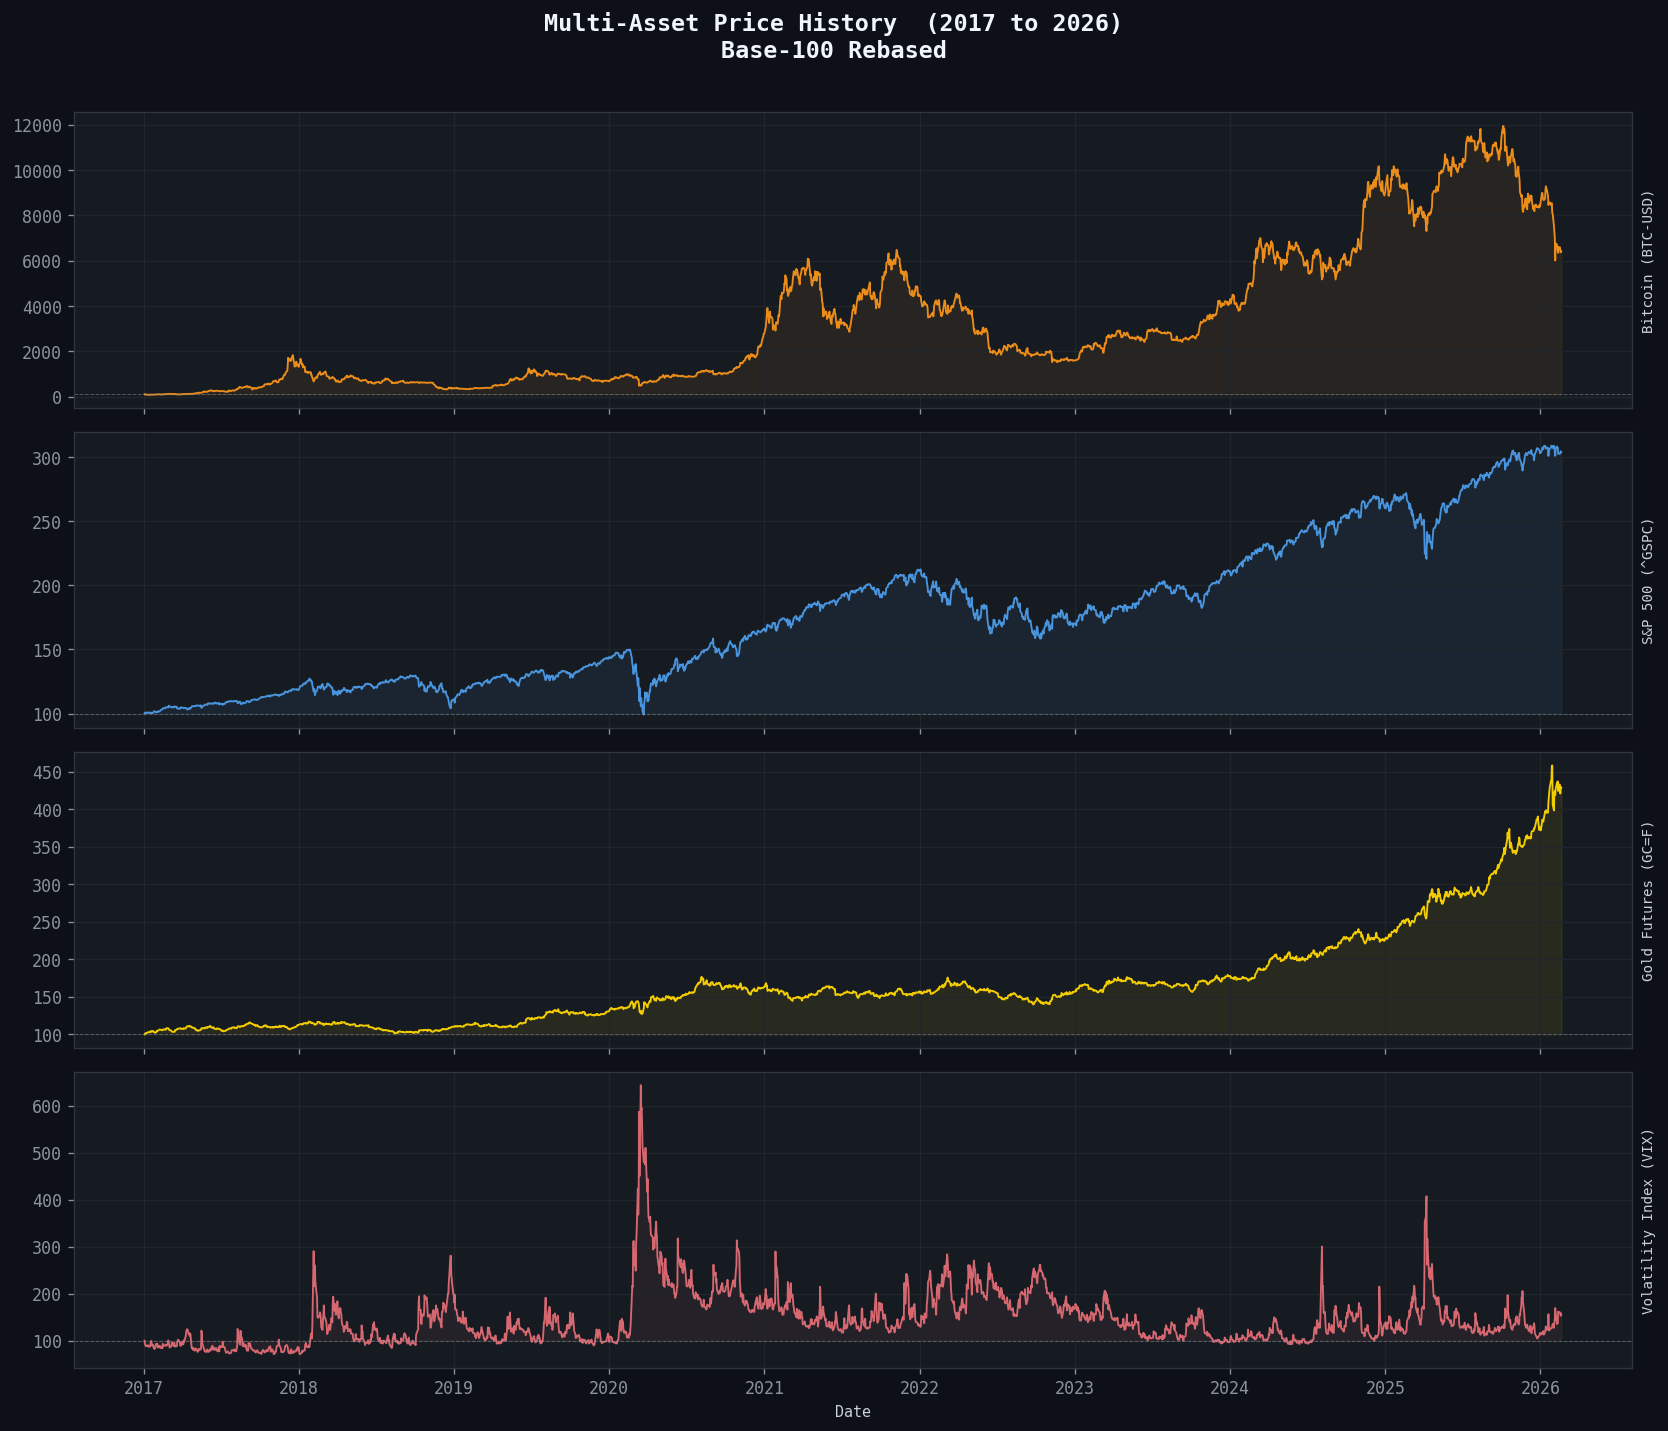

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Multi-Asset Price History  (2017 to 2026)\nBase-100 Rebased",
             fontsize=14, color="#f0f6fc", fontweight="bold", y=0.99)

asset_cfg = [
    ("BTC",   "Bitcoin (BTC-USD)",      PALETTE["btc"]),
    ("SP500", "S&P 500 (^GSPC)",        PALETTE["sp500"]),
    ("GOLD",  "Gold Futures (GC=F)",    PALETTE["gold"]),
    ("VIX",   "Volatility Index (VIX)", PALETTE["vix"]),
]

for ax, (col, label, color) in zip(axes, asset_cfg):
    normed = prices[col] / prices[col].iloc[0] * 100
    ax.plot(normed.index, normed.values, color=color, linewidth=1.1, alpha=0.95)
    ax.fill_between(normed.index, normed.values, 100, alpha=0.08, color=color)
    ax.axhline(100, color=PALETTE["muted"], linewidth=0.6, linestyle="--", alpha=0.5)
    ax.set_ylabel(label, fontsize=8.5, labelpad=6)
    ax.yaxis.set_label_position("right")

axes[-1].set_xlabel("Date", fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.98])
_save(fig, "01_price_history.png")
plt.show()

---
## Step 3: Feature Engineering

The feature matrix is derived entirely from past price data. Every transformation is designed to be **look-ahead free** -- at any date `t`, only information available up to and including `t` is used.

**Important note on cross-asset ratios:** All ratio features (`btc_sp500_ratio`, `btc_gold_ratio`, `sp500_gold_ratio`) are computed from prices lagged by one day. Using the same-day closing price would introduce an execution ambiguity: the closing price is only observed at market close, which is the same moment the target is defined. Lagging by one day ensures every feature is strictly observable before the prediction must be made.

| Feature Group | Features |
|---|---|
| **Daily log-returns** | `btc_ret`, `sp500_ret`, `gold_ret`, `vix_ret` |
| **Rolling volatility** (annualised sigma) | `btc_vol_7d`, `btc_vol_30d`, `sp500_vol_7d`, `sp500_vol_30d`, `vix_vol_7d`, `vix_vol_30d` |
| **Momentum** (price / MA - 1) | `btc_mom7`, `btc_mom30`, `sp500_mom7`, `sp500_mom30` |
| **Lagged returns** | `btc_ret_lag1` to `btc_ret_lag5`, `sp500_ret_lag1` to `lag3` |
| **Lagged VIX levels** | `vix_lag1`, `vix_lag2`, `vix_lag3` |
| **Cross-asset ratios** (lagged 1 day) | `btc_sp500_ratio_lag1`, `btc_gold_ratio_lag1`, `sp500_gold_ratio_lag1` |
| **VIX signals** | `vix_level_lag1`, `vix_change`, `vix_zscore` |
| **Regime signal** | `btc_sp500_corr30` (rolling 30-day return correlation) |

### Target Variable -- Leak-Free Construction

The target is `1` (high risk) if **next-day** BTC realised volatility exceeds the **expanding historical median** computed from all past data up to that point only.

```python
# CORRECT: expanding median -- only uses past data at every point in time
threshold = next_day_vol.expanding().median()
target    = (next_day_vol > threshold).astype(int)
```

This is the critical difference from a naive global median, which would use future test-set data to set the threshold -- a form of data leakage that inflates performance.

### 3.0: What Each Feature Means and Why It Was Chosen

**Daily Log-Returns** (`btc_ret`, `sp500_ret`, `gold_ret`, `vix_ret`)

A log-return is `log(today's price / yesterday's price)`. It measures how much an asset moved as a continuous percentage. Log-returns are preferred over simple returns because they are additive across time, more symmetrically distributed, and better behaved statistically. These are the raw signals everything else is built from.

**Rolling Volatility** (`btc_vol_7d`, `btc_vol_30d`, `sp500_vol_7d`, `sp500_vol_30d`)

Volatility is the standard deviation of log-returns over a rolling window, multiplied by sqrt(252) to annualise it. The 7-day version captures recent turbulence; the 30-day version reflects the broader trend. Volatility clusters in financial markets: a turbulent today strongly predicts a turbulent tomorrow. These features give the model direct access to that clustering effect.

**Momentum** (`btc_mom7`, `btc_mom30`, `sp500_mom7`, `sp500_mom30`)

Momentum is `(price / rolling_moving_average) - 1`. Positive means trading above the recent average (upward trend); negative means below (downward pressure). Sustained downward moves in BTC or SP500 tend to coincide with elevated fear and higher future volatility.

**Lagged Returns** (`btc_ret_lag1` through `btc_ret_lag5`, `sp500_ret_lag1` through `lag3`)

Lagged returns capture short-term autocorrelation: a large negative return yesterday tends to be followed by continued instability. Five lags for BTC and three for SP500 covers roughly one trading week without flooding the model with correlated inputs.

**Lagged VIX Levels** (`vix_lag1`, `vix_lag2`, `vix_lag3`)

The VIX is the market's forward-looking estimate of 30-day SP500 volatility derived from options prices. A rising VIX signals that professional participants are paying up for protection -- a leading indicator of stress. Including three daily VIX readings lets the model detect whether fear is building, peaking, or fading.

**Cross-Asset Ratios (lagged 1 day)** (`btc_sp500_ratio_lag1`, `btc_gold_ratio_lag1`, `sp500_gold_ratio_lag1`)

These ratios capture relative strength between assets. When BTC falls sharply relative to SP500 it can indicate crypto-specific stress unrelated to macro. When gold rises relative to equities it typically signals a flight to safety. All three ratios are lagged by one business day so that no same-day closing price enters the feature set.

**VIX-Derived Signals** (`vix_level_lag1`, `vix_change`, `vix_zscore`)

`vix_level_lag1` is the prior day's raw VIX reading. `vix_change` is the day-over-day difference, capturing sudden spikes. `vix_zscore` normalises the VIX against its own 30-day history so the model distinguishes between a VIX of 25 that is unusually elevated versus one that is in line with a recently turbulent period.

**Rolling BTC/SP500 Correlation** (`btc_sp500_corr30`)

This is the 30-day rolling Pearson correlation between BTC and SP500 daily returns. During normal periods the correlation is modest. During systemic events such as March 2020 or the 2022 rate shock, it spikes toward 1.0 as all risk assets sell off together. A rising correlation is a direct measure of systemic market stress.

**Target Variable** (`target`)

The target is 1 (high risk) if next-day BTC realised 7-day volatility exceeds the expanding historical median, and 0 (low risk) otherwise. Using an expanding median rather than the full-sample median is critical: the threshold at any date `t` is computed from data before `t` only.

In [19]:
def build_features(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Construct the full feature matrix from clean price data.

    All features are strictly look-ahead free:
      - Rolling statistics use only past observations.
      - Cross-asset ratios are lagged by 1 day to avoid execution ambiguity.
      - The target uses an expanding median threshold, not the full-sample median.

    Parameters
    ----------
    prices : pd.DataFrame  Clean, business-day aligned prices.

    Returns
    -------
    pd.DataFrame  Feature matrix including the binary 'target' column.
    """
    log.info("\n" + "=" * 70)
    log.info("STEP 3 - FEATURE ENGINEERING")
    log.info("=" * 70)

    df = pd.DataFrame(index=prices.index)

    # 3a. Daily log-returns
    for col in ["BTC", "SP500", "GOLD", "VIX"]:
        df[f"{col.lower()}_ret"] = np.log(prices[col] / prices[col].shift(1))

    # 3b. Rolling volatility (annualised)
    for window in [SHORT_WINDOW, LONG_WINDOW]:
        df[f"btc_vol_{window}d"]   = df["btc_ret"].rolling(window).std() * np.sqrt(252)
        df[f"sp500_vol_{window}d"] = df["sp500_ret"].rolling(window).std() * np.sqrt(252)
        df[f"vix_vol_{window}d"]   = df["vix_ret"].rolling(window).std() * np.sqrt(252)

    # 3c. Moving averages and momentum
    for window in [SHORT_WINDOW, LONG_WINDOW]:
        ma_btc   = prices["BTC"].rolling(window).mean()
        ma_sp500 = prices["SP500"].rolling(window).mean()
        df[f"btc_mom{window}"]   = prices["BTC"]   / ma_btc   - 1
        df[f"sp500_mom{window}"] = prices["SP500"] / ma_sp500 - 1

    # 3d. Lagged returns (t-1 to t-5 for BTC, t-1 to t-3 for SP500)
    for lag in range(1, 6):
        df[f"btc_ret_lag{lag}"] = df["btc_ret"].shift(lag)
    for lag in range(1, 4):
        df[f"sp500_ret_lag{lag}"] = df["sp500_ret"].shift(lag)

    # 3e. Lagged VIX levels
    for lag in range(1, 4):
        df[f"vix_lag{lag}"] = prices["VIX"].shift(lag)

    # 3f. Cross-asset ratios -- LAGGED by 1 day to prevent execution ambiguity.
    # Using same-day closing prices would mean these features are only
    # observable at the same time as the target. Lagging by 1 makes them
    # strictly available before any trade decision.
    df["btc_sp500_ratio_lag1"]  = (prices["BTC"]   / prices["SP500"]).shift(1)
    df["btc_gold_ratio_lag1"]   = (prices["BTC"]   / prices["GOLD"]).shift(1)
    df["sp500_gold_ratio_lag1"] = (prices["SP500"] / prices["GOLD"]).shift(1)

    # 3g. VIX level signals
    # vix_level is lagged to maintain strict look-ahead freedom
    df["vix_level_lag1"] = prices["VIX"].shift(1)
    df["vix_change"]     = prices["VIX"].diff()
    df["vix_zscore"]     = (
        (prices["VIX"] - prices["VIX"].rolling(LONG_WINDOW).mean())
        / prices["VIX"].rolling(LONG_WINDOW).std()
    )

    # 3h. Rolling BTC / SP500 return correlation
    df["btc_sp500_corr30"] = (
        df["btc_ret"].rolling(LONG_WINDOW).corr(df["sp500_ret"])
    )

    # 3i. Target: LEAK-FREE expanding median threshold
    #
    # next_day_vol  : BTC realised vol shifted back one day (what we predict)
    # threshold     : expanding median of next_day_vol -- at time t, this is the
    #                 median of all values from the start up to t, no future data.
    #
    # Using the full-sample median would constitute data leakage because
    # the test-set distribution influences the threshold used in training.
    next_day_vol = df[f"btc_vol_{VOLATILITY_WINDOW}d"].shift(-1)
    threshold    = next_day_vol.expanding().median()
    df["target"] = (next_day_vol > threshold).astype(int)

    log.info(f"  Feature columns  : {df.shape[1] - 1}")
    log.info(f"  High-risk (1)    : {df['target'].sum():,}  ({df['target'].mean():.1%})")
    log.info(f"  Low-risk  (0)    : {(df['target'] == 0).sum():,}  ({(df['target'] == 0).mean():.1%})")

    df.to_csv(DATA_DIR / "features.csv")
    log.info(f"  Persisted feature matrix to {DATA_DIR / 'features.csv'}")

    return df


df = build_features(prices)
print(f"\nFeature matrix: {df.shape[0]:,} rows x {df.shape[1]} columns (incl. target)")
df.head(3)

14:48:12  INFO      
14:48:12  INFO      STEP 3 - FEATURE ENGINEERING
14:48:12  INFO      ======================================================================
14:48:12  INFO        Feature columns  : 32
14:48:12  INFO        High-risk (1)    : 858  (36.0%)
14:48:12  INFO        Low-risk  (0)    : 1,525  (64.0%)
14:48:13  INFO        Persisted feature matrix to data\features.csv



Feature matrix: 2,383 rows x 33 columns (incl. target)


,btc_ret,sp500_ret,gold_ret,vix_ret,btc_vol_7d,sp500_vol_7d,vix_vol_7d,btc_vol_30d,sp500_vol_30d,vix_vol_30d,...,vix_lag2,vix_lag3,btc_sp500_ratio_lag1,btc_gold_ratio_lag1,sp500_gold_ratio_lag1,vix_level_lag1,vix_change,vix_zscore,btc_sp500_corr30,target
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2017-01-04,0.100960,0.005706,0.002926,-0.081016,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.462320,0.899552,1.945734,12.85,-1.00,NaN,NaN,0
2017-01-05,-0.130575,-0.000771,0.013570,-0.015306,NaN,NaN,NaN,NaN,NaN,NaN,...,12.85,NaN,0.508524,0.992207,1.951151,11.85,-0.18,NaN,NaN,0


### 3.1: Rolling Class Balance Over Time

The expanding median construction guarantees approximately 50/50 class balance globally, but the actual ratio can drift substantially within subperiods -- especially during prolonged bull markets (low-risk days dominate) or crisis periods (high-risk days cluster). Tracking this over time reveals when the model faces the hardest classification environment.

14:48:13  INFO        Saved figure: results\figures\02_rolling_class_balance.png


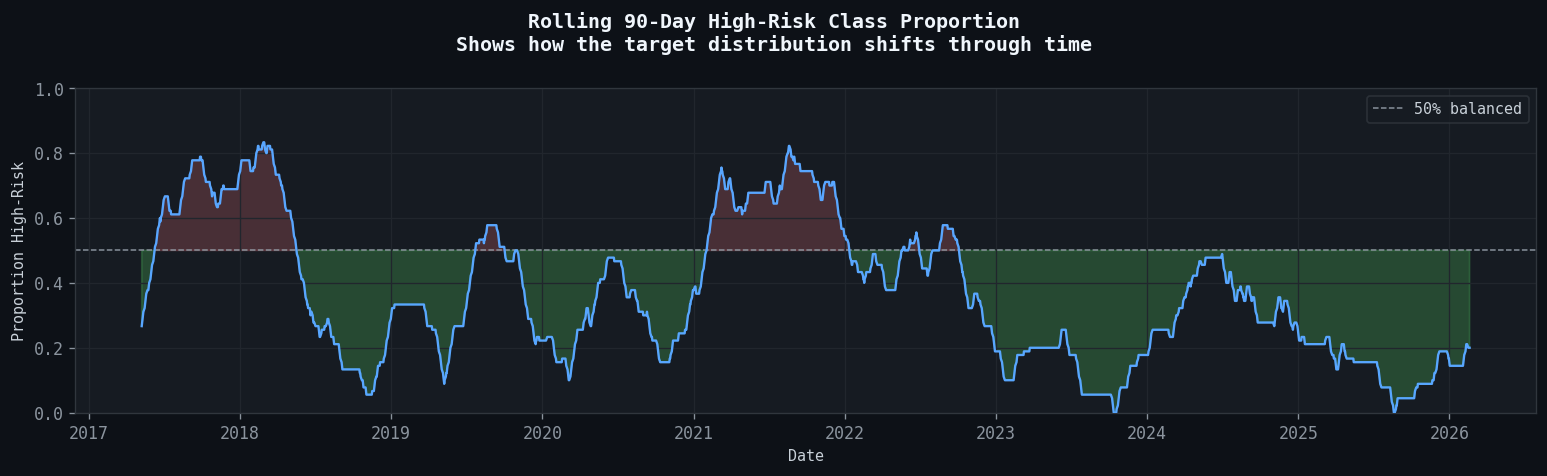

In [20]:
# Rolling 90-day class proportion to see how the target drifts
target_clean = df["target"].dropna()
rolling_highrisk = target_clean.rolling(90).mean()

fig, ax = plt.subplots(figsize=(13, 4))
fig.suptitle("Rolling 90-Day High-Risk Class Proportion\n"
             "Shows how the target distribution shifts through time",
             fontsize=12, color="#f0f6fc", fontweight="bold")

ax.plot(rolling_highrisk.index, rolling_highrisk.values,
        color=PALETTE["accent"], linewidth=1.4, zorder=3)
ax.fill_between(rolling_highrisk.index, rolling_highrisk.values, 0.5,
                where=(rolling_highrisk.values > 0.5),
                alpha=0.25, color=PALETTE["neg"], interpolate=True)
ax.fill_between(rolling_highrisk.index, rolling_highrisk.values, 0.5,
                where=(rolling_highrisk.values <= 0.5),
                alpha=0.25, color=PALETTE["pos"], interpolate=True)
ax.axhline(0.5, color=PALETTE["muted"], linewidth=0.9,
           linestyle="--", label="50% balanced")
ax.set_ylabel("Proportion High-Risk", fontsize=9)
ax.set_xlabel("Date", fontsize=9)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
fig.tight_layout()
_save(fig, "02_rolling_class_balance.png")
plt.show()

### 3.2: Feature Correlation Heatmap

14:48:16  INFO        Saved figure: results\figures\03_correlation_heatmap.png


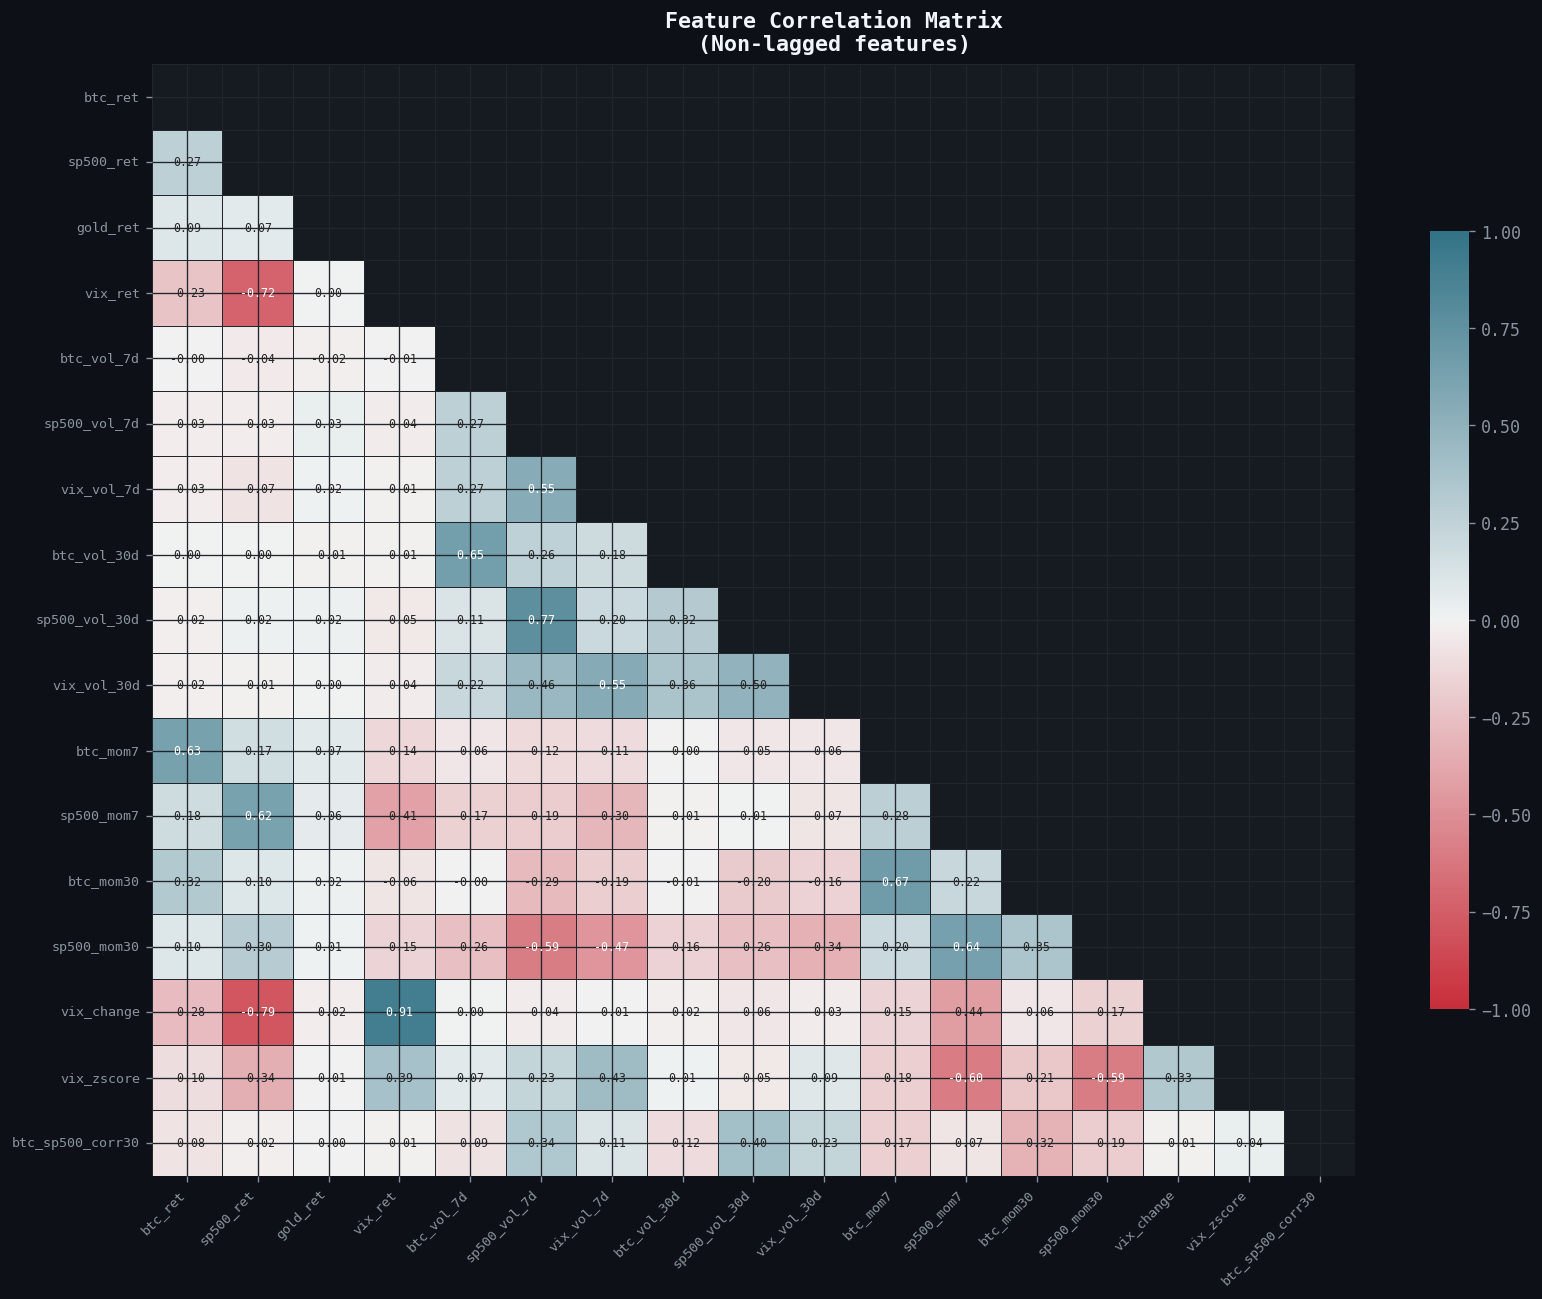

In [21]:
feature_cols_all = [c for c in df.columns if c != "target"]

key_features = [c for c in feature_cols_all if any(
    kw in c for kw in ["ret", "vol", "mom", "ratio", "vix", "corr"]
) and "lag" not in c]

corr = df[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle("Feature Correlation Matrix\n(Non-lagged features)",
             fontsize=13, color="#f0f6fc", fontweight="bold")

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap=sns.diverging_palette(10, 220, s=80, l=45, as_cmap=True),
    center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.3, linecolor="#21262d",
    cbar_kws={"shrink": 0.7},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
fig.tight_layout()
_save(fig, "03_correlation_heatmap.png")
plt.show()

### 3.3: BTC Price with Risk Regime Overlay

14:48:18  INFO        Saved figure: results\figures\04_risk_regime_overlay.png


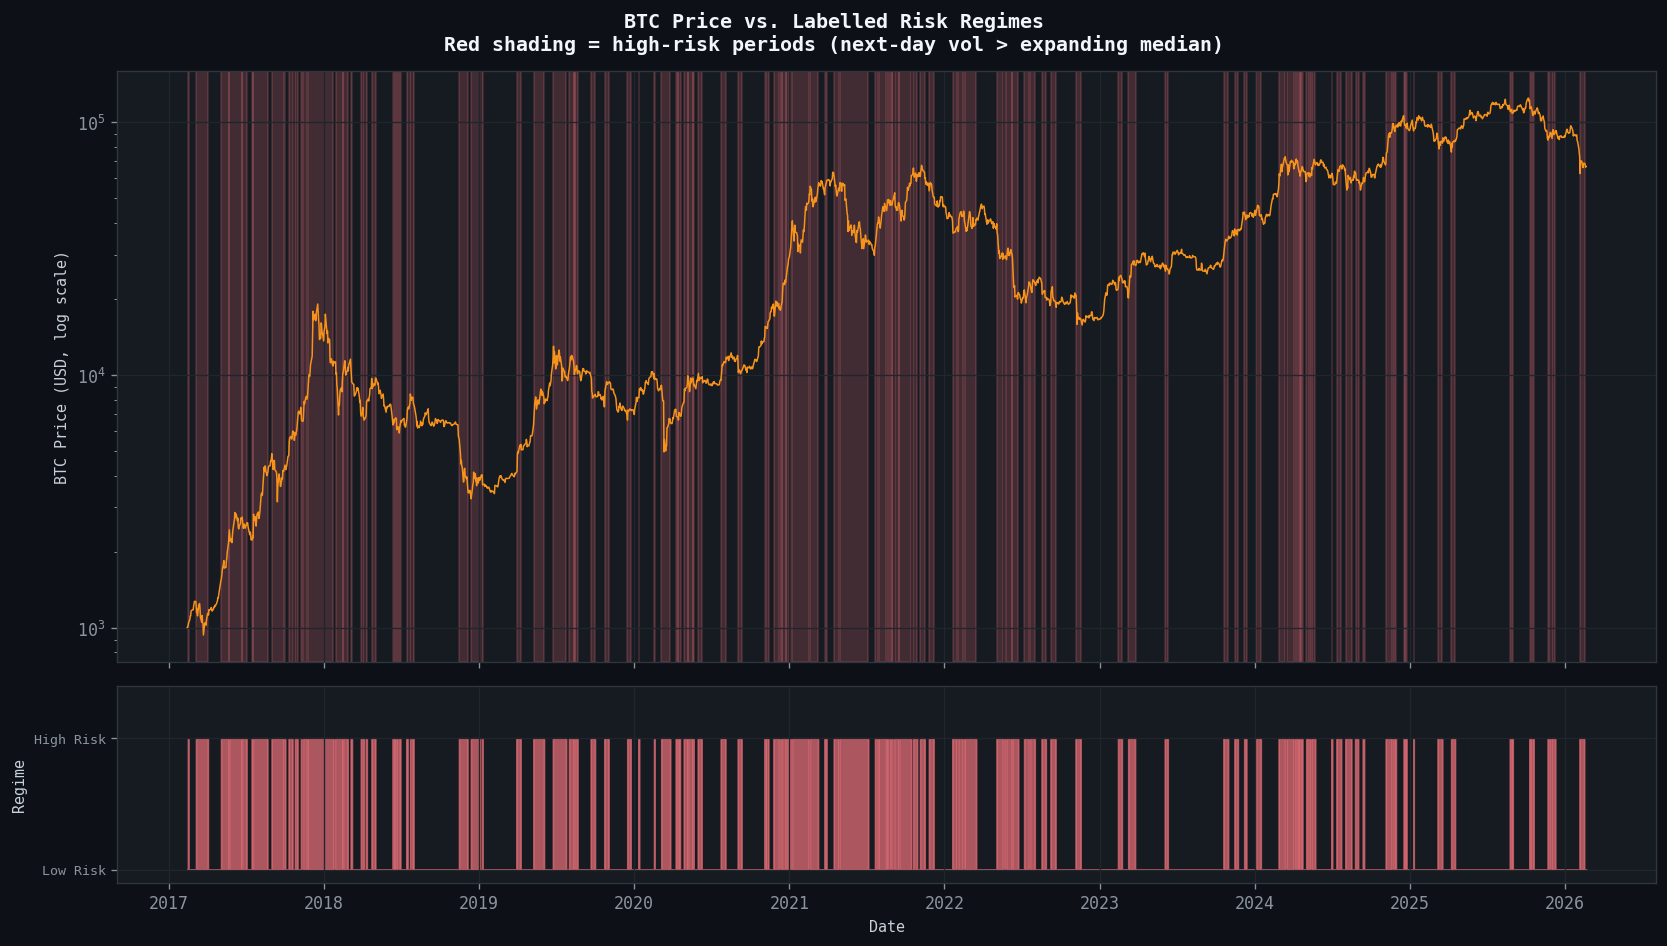

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("BTC Price vs. Labelled Risk Regimes\n"
             "Red shading = high-risk periods (next-day vol > expanding median)",
             fontsize=12, color="#f0f6fc", fontweight="bold")

common_idx = prices.index.intersection(df.dropna().index)
btc  = prices.loc[common_idx, "BTC"]
risk = df.loc[common_idx, "target"]

ax0 = axes[0]
ax0.plot(btc.index, btc.values, color=PALETTE["btc"], linewidth=0.9, zorder=3)
ax0.set_ylabel("BTC Price (USD, log scale)", fontsize=9)
ax0.set_yscale("log")

in_risk, start = False, None
for date, val in risk.items():
    if val == 1 and not in_risk:
        start, in_risk = date, True
    elif val == 0 and in_risk:
        ax0.axvspan(start, date, alpha=0.22, color=PALETTE["neg"], zorder=1)
        in_risk = False
if in_risk:
    ax0.axvspan(start, risk.index[-1], alpha=0.22, color=PALETTE["neg"])

ax1 = axes[1]
ax1.fill_between(risk.index, risk.values, color=PALETTE["neg"], alpha=0.75, step="mid")
ax1.set_ylim(-0.1, 1.4)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(["Low Risk", "High Risk"], fontsize=8)
ax1.set_ylabel("Regime", fontsize=9)
ax1.set_xlabel("Date", fontsize=9)

fig.tight_layout()
_save(fig, "04_risk_regime_overlay.png")
plt.show()

---
## Step 4: Train / Test Split (Chronological)

Financial time series must **never** be split randomly. Doing so allows the model to train on future data and produces unrealistically optimistic results.

We use a strict **chronological 80/20 split**:
- Training set: all data up to the split date
- Test set: the most recent 20% of the data, unseen during training

In [23]:
def prepare_splits(df: pd.DataFrame):
    """
    Chronological 80/20 train-test split. No shuffling.

    Returns
    -------
    X_train, X_test, y_train, y_test : pd.DataFrame / pd.Series
    feature_cols                      : list[str]
    """
    log.info("\n" + "=" * 70)
    log.info("STEP 4 - TRAIN / TEST SPLIT  (chronological 80 / 20)")
    log.info("=" * 70)

    feature_cols = [c for c in df.columns if c != "target"]
    df_clean = df[feature_cols + ["target"]].dropna()

    X = df_clean[feature_cols]
    y = df_clean["target"]

    split_idx = int(len(X) * 0.80)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    log.info(f"  Training : {len(X_train):,} rows  ({X_train.index[0].date()} to {X_train.index[-1].date()})")
    log.info(f"  Test     : {len(X_test):,}  rows  ({X_test.index[0].date()} to {X_test.index[-1].date()})")
    log.info(f"  Features : {X.shape[1]}")
    log.info(f"  Train class balance  --  High: {y_train.mean():.1%}  |  Low: {(1-y_train.mean()):.1%}")
    log.info(f"  Test  class balance  --  High: {y_test.mean():.1%}  |  Low: {(1-y_test.mean()):.1%}")

    return X_train, X_test, y_train, y_test, feature_cols


X_train, X_test, y_train, y_test, feature_cols = prepare_splits(df)
print(f"Training set : {X_train.shape}  |  Test set : {X_test.shape}")

14:48:19  INFO      
14:48:19  INFO      STEP 4 - TRAIN / TEST SPLIT  (chronological 80 / 20)
14:48:19  INFO      ======================================================================
14:48:19  INFO        Training : 1,882 rows  (2017-02-14 to 2024-05-01)
14:48:19  INFO        Test     : 471  rows  (2024-05-02 to 2026-02-19)
14:48:19  INFO        Features : 32
14:48:19  INFO        Train class balance  --  High: 40.5%  |  Low: 59.5%
14:48:19  INFO        Test  class balance  --  High: 20.2%  |  Low: 79.8%


Training set : (1882, 32)  |  Test set : (471, 32)


---
## Step 5: Modeling

### Model Choices

Three classifiers are evaluated, each embedded in a `StandardScaler -> Classifier` pipeline:

| Model | Rationale |
|---|---|
| **Logistic Regression** | Linear baseline; interpretable coefficients; regularised with `C=0.1` |
| **Ridge Classifier (Calibrated)** | Ridge regression adapted for classification; wrapped in `CalibratedClassifierCV` to produce well-calibrated probability estimates comparable to LR |
| **Random Forest** | Non-linear ensemble; captures interactions; provides feature importances |

**Note on Ridge calibration:** The standard `RidgeClassifier` does not have `predict_proba`. A common workaround is to min-max normalise the decision function, but those scores are not true probabilities and produce ROC-AUC values that are not comparable across models. Here we wrap Ridge in `CalibratedClassifierCV` with Platt scaling, which fits a logistic regression on top of the decision function scores to produce genuine probability estimates.

### Cross-Validation

`TimeSeriesSplit` (5 folds) on the training set. Each validation fold always follows its training fold chronologically.

### Baseline

A **naive persistence baseline** predicts today's regime as whatever it was yesterday. This is the minimum bar any trained model must clear to demonstrate genuine predictive value.

In [24]:
def build_models() -> dict:
    """
    Construct sklearn Pipeline objects for each classifier.

    Ridge Classifier is wrapped in CalibratedClassifierCV so that its
    predict_proba output is directly comparable to Logistic Regression.
    Min-max normalisation of the decision function is NOT used here
    because those scores are not calibrated probabilities.

    Returns
    -------
    dict  {model_name: sklearn.pipeline.Pipeline}
    """
    ridge_base = RidgeClassifier(alpha=1.0, random_state=RANDOM_SEED)
    ridge_calibrated = CalibratedClassifierCV(
        ridge_base, method="sigmoid", cv=3
    )

    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                C=0.1,
                solver="lbfgs",
                class_weight="balanced",
                random_state=RANDOM_SEED,
            )),
        ]),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", ridge_calibrated),
        ]),
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=20,
                max_features="sqrt",
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_SEED,
            )),
        ]),
    }


print("Model definitions ready.")

Model definitions ready.


In [25]:
def train_and_evaluate(
    models: dict,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> tuple:
    """
    Train each model, evaluate on the hold-out test set, return per-model
    results and a consolidated summary DataFrame.

    Parameters
    ----------
    models  : dict   {name: Pipeline}
    X_train : pd.DataFrame
    X_test  : pd.DataFrame
    y_train : pd.Series
    y_test  : pd.Series

    Returns
    -------
    results : dict           Per-model predictions, probabilities, metrics
    summary : pd.DataFrame   Consolidated metrics table
    """
    log.info("\n" + "=" * 70)
    log.info("STEP 5 - TRAINING AND EVALUATION")
    log.info("=" * 70)

    tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
    results = {}

    # Baseline: naive persistence
    log.info("\n  Baseline (Naive Persistence: predict yesterday's label)")

    y_pred_baseline = y_test.shift(1).ffill().bfill().astype(int)

    b_acc  = accuracy_score(y_test, y_pred_baseline)
    b_prec = precision_score(y_test, y_pred_baseline, zero_division=0)
    b_rec  = recall_score(y_test, y_pred_baseline, zero_division=0)
    b_f1   = f1_score(y_test, y_pred_baseline, zero_division=0)

    log.info(f"    Accuracy   : {b_acc:.4f}")
    log.info(f"    Precision  : {b_prec:.4f}")
    log.info(f"    Recall     : {b_rec:.4f}")
    log.info(f"    F1-Score   : {b_f1:.4f}")

    results["Baseline (Persistence)"] = {
        "pipeline"    : None,
        "y_pred"      : y_pred_baseline,
        "y_prob"      : y_pred_baseline.astype(float),
        "CV_AUC_mean" : float("nan"),
        "CV_AUC_std"  : float("nan"),
        "Accuracy"    : b_acc,
        "Precision"   : b_prec,
        "Recall"      : b_rec,
        "F1"          : b_f1,
        "ROC_AUC"     : float("nan"),
        "Brier"       : float("nan"),
    }

    # ML Models
    for name, pipeline in models.items():
        log.info(f"\n  {name}")

        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=tscv, scoring="roc_auc", n_jobs=-1,
        )
        log.info(f"    CV ROC-AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        # All three models now support predict_proba (Ridge is calibrated)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        acc   = accuracy_score(y_test, y_pred)
        prec  = precision_score(y_test, y_pred, zero_division=0)
        rec   = recall_score(y_test, y_pred, zero_division=0)
        f1    = f1_score(y_test, y_pred, zero_division=0)
        auc   = roc_auc_score(y_test, y_prob)
        brier = brier_score_loss(y_test, y_prob)

        log.info(f"    Accuracy   : {acc:.4f}")
        log.info(f"    Precision  : {prec:.4f}")
        log.info(f"    Recall     : {rec:.4f}")
        log.info(f"    F1-Score   : {f1:.4f}")
        log.info(f"    ROC-AUC    : {auc:.4f}")
        log.info(f"    Brier Score: {brier:.4f}  (lower is better)")

        results[name] = {
            "pipeline"    : pipeline,
            "y_pred"      : y_pred,
            "y_prob"      : y_prob,
            "CV_AUC_mean" : cv_scores.mean(),
            "CV_AUC_std"  : cv_scores.std(),
            "Accuracy"    : acc,
            "Precision"   : prec,
            "Recall"      : rec,
            "F1"          : f1,
            "ROC_AUC"     : auc,
            "Brier"       : brier,
        }

    metric_cols = ["CV_AUC_mean", "CV_AUC_std", "Accuracy", "Precision",
                   "Recall", "F1", "ROC_AUC", "Brier"]
    summary = pd.DataFrame(
        {k: {m: v for m, v in results[k].items() if m in metric_cols}
         for k in results}
    ).T.astype(float)

    summary.to_csv(OUTPUT_DIR / "model_results.csv")
    log.info(f"\n  Results saved to {OUTPUT_DIR / 'model_results.csv'}")

    return results, summary


models  = build_models()
results, summary = train_and_evaluate(models, X_train, X_test, y_train, y_test)

14:48:19  INFO      
14:48:19  INFO      STEP 5 - TRAINING AND EVALUATION
14:48:19  INFO      ======================================================================
14:48:19  INFO      
  Baseline (Naive Persistence: predict yesterday's label)
14:48:19  INFO          Accuracy   : 0.9002
14:48:19  INFO          Precision  : 0.7500
14:48:19  INFO          Recall     : 0.7579
14:48:19  INFO          F1-Score   : 0.7539
14:48:19  INFO      
  Logistic Regression


14:48:27  INFO          CV ROC-AUC : 0.8705 +/- 0.0717
14:48:27  INFO          Accuracy   : 0.8854
14:48:27  INFO          Precision  : 0.7253
14:48:27  INFO          Recall     : 0.6947
14:48:27  INFO          F1-Score   : 0.7097
14:48:27  INFO          ROC-AUC    : 0.9172
14:48:27  INFO          Brier Score: 0.1014  (lower is better)
14:48:27  INFO      
  Ridge Classifier
14:48:32  INFO          CV ROC-AUC : 0.7953 +/- 0.1034
14:48:32  INFO          Accuracy   : 0.8556
14:48:32  INFO          Precision  : 0.6484
14:48:32  INFO          Recall     : 0.6211
14:48:32  INFO          F1-Score   : 0.6344
14:48:32  INFO          ROC-AUC    : 0.8662
14:48:32  INFO          Brier Score: 0.1587  (lower is better)
14:48:32  INFO      
  Random Forest
14:48:39  INFO          CV ROC-AUC : 0.9222 +/- 0.0131
14:48:41  INFO          Accuracy   : 0.8917
14:48:41  INFO          Precision  : 0.8438
14:48:41  INFO          Recall     : 0.5684
14:48:41  INFO          F1-Score   : 0.6792
14:48:41  INFO  

---
## Step 6: Results Summary

In [26]:
display_cols = ["CV_AUC_mean", "CV_AUC_std", "Accuracy", "Precision",
                "Recall", "F1", "ROC_AUC", "Brier"]
best_model   = summary.loc[summary["ROC_AUC"].notna(), "ROC_AUC"].idxmax()

print(f"{'Model':<30} {'CV-AUC':>9} {'+-':>6} {'Accuracy':>10} {'Precision':>11} "
      f"{'Recall':>8} {'F1':>7} {'ROC-AUC':>9} {'Brier':>7}")
print("-" * 105)

for model, row in summary[display_cols].iterrows():
    cv   = f"{row['CV_AUC_mean']:.4f}" if not pd.isna(row["CV_AUC_mean"]) else "  -   "
    cv_s = f"{row['CV_AUC_std']:.4f}"  if not pd.isna(row["CV_AUC_std"])  else "  -  "
    auc  = f"{row['ROC_AUC']:.4f}"     if not pd.isna(row["ROC_AUC"])     else "  -   "
    brier = f"{row['Brier']:.4f}"      if not pd.isna(row["Brier"])       else "  -  "
    flag = "  BEST" if model == best_model else ""
    print(
        f"{model:<30} {cv:>9} {cv_s:>6} "
        f"{row['Accuracy']:>10.4f} {row['Precision']:>11.4f} "
        f"{row['Recall']:>8.4f} {row['F1']:>7.4f} {auc:>9} {brier:>7}{flag}"
    )

print(f"\nBest model: {best_model}  |  Test ROC-AUC: {summary.loc[best_model, 'ROC_AUC']:.4f}")

Model                             CV-AUC     +-   Accuracy   Precision   Recall      F1   ROC-AUC   Brier
---------------------------------------------------------------------------------------------------------
Baseline (Persistence)              -       -       0.9002      0.7500   0.7579  0.7539      -        -  
Logistic Regression               0.8705 0.0717     0.8854      0.7253   0.6947  0.7097    0.9172  0.1014  BEST
Ridge Classifier                  0.7953 0.1034     0.8556      0.6484   0.6211  0.6344    0.8662  0.1587
Random Forest                     0.9222 0.0131     0.8917      0.8438   0.5684  0.6792    0.9132  0.0995

Best model: Logistic Regression  |  Test ROC-AUC: 0.9172


In [27]:
# Full classification report for the best model
print(f"Classification Report -- {best_model}\n")
print(classification_report(
    y_test, results[best_model]["y_pred"],
    target_names=["Low Risk (0)", "High Risk (1)"],
))

report_text = classification_report(
    y_test, results[best_model]["y_pred"],
    target_names=["Low Risk (0)", "High Risk (1)"],
)
report_path = OUTPUT_DIR / "classification_report.txt"
with open(report_path, "w") as f:
    f.write(f"Best Model: {best_model}\n\n")
    f.write(report_text)
print(f"Saved to {report_path}")

Classification Report -- Logistic Regression

               precision    recall  f1-score   support

 Low Risk (0)       0.92      0.93      0.93       376
High Risk (1)       0.73      0.69      0.71        95

     accuracy                           0.89       471
    macro avg       0.82      0.81      0.82       471
 weighted avg       0.88      0.89      0.88       471

Saved to results\classification_report.txt


---
## Step 7: Statistical Significance -- Diebold-Mariano Test

### Why Not a Welch t-test?

A Welch t-test assumes that the two samples being compared are independent. Prediction errors from a time-series model are not independent: adjacent days are correlated by construction. Using a Welch t-test on autocorrelated forecast errors inflates the test statistic, making it falsely easy to reject the null hypothesis.

The **Diebold-Mariano (DM) test** was designed specifically for comparing the forecast accuracy of two models on dependent time-series data. It accounts for serial correlation in the loss differential series by using a long-run variance estimator (Newey-West HAC). This is the standard in academic finance and econometrics for this type of comparison.

**Null hypothesis (H0):** The two models have equal predictive accuracy.  
**Alternative (H1):** The ML model has better predictive accuracy than the baseline.

The loss function used here is squared error on the probability forecasts, which penalises confident wrong predictions more than uncertain ones.

In [28]:
def diebold_mariano_test(
    y_true: np.ndarray,
    y_prob_model: np.ndarray,
    y_prob_baseline: np.ndarray,
    h: int = 1,
    power: int = 2,
) -> dict:
    """
    Diebold-Mariano test for equal predictive accuracy.

    Uses Newey-West HAC variance estimator to handle autocorrelation
    in the loss differential series, which is the correct approach
    for time-series forecast comparison.

    Parameters
    ----------
    y_true          : np.ndarray  Actual outcomes (0 or 1)
    y_prob_model    : np.ndarray  Probability forecasts from ML model
    y_prob_baseline : np.ndarray  Probability forecasts from baseline
    h               : int         Forecast horizon (1 for one-step-ahead)
    power           : int         Loss function power (2 = squared error)

    Returns
    -------
    dict with dm_stat, p_value, n, conclusion
    """
    y_true = np.asarray(y_true, dtype=float)
    y_prob_model    = np.asarray(y_prob_model, dtype=float)
    y_prob_baseline = np.asarray(y_prob_baseline, dtype=float)

    # Loss differentials: positive means model has lower loss (better)
    loss_model    = np.abs(y_true - y_prob_model)    ** power
    loss_baseline = np.abs(y_true - y_prob_baseline) ** power
    d = loss_baseline - loss_model

    n      = len(d)
    d_mean = d.mean()

    # Newey-West HAC variance with bandwidth proportional to h
    # This corrects for serial correlation in d up to h lags
    bandwidth = int(np.ceil(h * (n ** (1/3))))
    gamma0    = np.var(d, ddof=1)
    hac_var   = gamma0
    for lag in range(1, bandwidth + 1):
        weight  = 1 - lag / (bandwidth + 1)   # Bartlett kernel
        gamma_k = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))
        hac_var += 2 * weight * gamma_k

    hac_var = max(hac_var, 1e-10)   # numerical guard
    dm_stat = d_mean / np.sqrt(hac_var / n)

    # Two-sided p-value from standard normal (large-sample approximation)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))

    conclusion = (
        "Reject H0: ML model has significantly better predictive accuracy (p < 0.05)."
        if p_value < 0.05 else
        "Fail to reject H0: no statistically significant difference in predictive accuracy."
    )

    return {
        "dm_stat"   : dm_stat,
        "p_value"   : p_value,
        "n"         : n,
        "d_mean"    : d_mean,
        "hac_var"   : hac_var,
        "bandwidth" : bandwidth,
        "conclusion": conclusion,
    }


# Run DM test for each ML model vs the baseline
# Baseline probability is just the 0/1 persistence prediction cast as float
baseline_prob = results["Baseline (Persistence)"]["y_pred"].astype(float).values
y_test_arr    = y_test.values

dm_results = {}
print("=" * 70)
print("  DIEBOLD-MARIANO TEST (HAC variance, Bartlett kernel)")
print("  H0: equal predictive accuracy vs Naive Persistence baseline")
print("  Loss function: squared error on probability forecasts")
print("=" * 70)

for name in [k for k in results if k != "Baseline (Persistence)"]:
    model_prob = results[name]["y_prob"]
    dm = diebold_mariano_test(y_test_arr, model_prob, baseline_prob)
    dm_results[name] = dm

    print(f"\n  Model: {name}")
    print(f"    Mean loss differential (baseline - model): {dm['d_mean']:+.6f}")
    print(f"    HAC variance (bandwidth={dm['bandwidth']}):            {dm['hac_var']:.6f}")
    print(f"    DM statistic:                              {dm['dm_stat']:+.4f}")
    print(f"    p-value (two-sided):                       {dm['p_value']:.6f}")
    print(f"    n observations:                            {dm['n']}")
    print(f"    {dm['conclusion']}")

print("=" * 70)

  DIEBOLD-MARIANO TEST (HAC variance, Bartlett kernel)
  H0: equal predictive accuracy vs Naive Persistence baseline
  Loss function: squared error on probability forecasts

  Model: Logistic Regression
    Mean loss differential (baseline - model): -0.001588
    HAC variance (bandwidth=8):            0.057419
    DM statistic:                              -0.1439
    p-value (two-sided):                       0.885615
    n observations:                            471
    Fail to reject H0: no statistically significant difference in predictive accuracy.

  Model: Ridge Classifier
    Mean loss differential (baseline - model): -0.058930
    HAC variance (bandwidth=8):            0.102607
    DM statistic:                              -3.9926
    p-value (two-sided):                       0.000065
    n observations:                            471
    Reject H0: ML model has significantly better predictive accuracy (p < 0.05).

  Model: Random Forest
    Mean loss differential (baseline

---
## Step 8: Feature Importance -- MDI vs Permutation Importance

### Why Both Methods?

**Mean Decrease in Impurity (MDI)** is the default importance metric from Random Forest. It is fast, but it has a known bias: it inflates the apparent importance of high-cardinality and continuous features. Features with more possible split points get more chances to be selected, and this shows up as higher importance even if the feature is not truly more predictive. This is documented in Strobl et al. (2007) and has been replicated many times.

**Permutation Importance** works differently: it measures the drop in model performance (on the test set) when one feature's values are randomly shuffled. Because shuffling breaks the relationship between that feature and the target, a large drop means the feature was genuinely contributing. This method is unbiased with respect to cardinality and is computed on held-out data, not training data.

Showing both and comparing them is the correct way to report feature attribution. Features that rank highly in both methods are reliable. Features that rank high only in MDI deserve skepticism.

In [29]:
# MDI importances from Random Forest
rf_pipeline  = results["Random Forest"]["pipeline"]
rf_clf       = rf_pipeline.named_steps["clf"]
mdi_values   = rf_clf.feature_importances_
mdi_series   = pd.Series(mdi_values, index=feature_cols).sort_values(ascending=False)

# Stability check: flag if any single feature dominates
max_imp     = mdi_series.iloc[0]
top_feature = mdi_series.index[0]

log.info(f"\n  MDI Feature stability check:")
log.info(f"    Max single-feature MDI importance: {max_imp:.4f}  ({top_feature})")

if max_imp > 0.30:
    log.warning(
        f"    ALERT: Dominant feature detected ({top_feature}: {max_imp:.3f}). "
        "Review for potential leakage or proxy variable."
    )
else:
    log.info("    OK: No single feature dominates -- MDI importances look well-distributed.")

print("\nTop 10 features by MDI:")
print(mdi_series.head(10).to_string())

14:48:41  INFO      
  MDI Feature stability check:
14:48:41  INFO          Max single-feature MDI importance: 0.4413  (btc_vol_7d)
14:48:41  WARNING       ALERT: Dominant feature detected (btc_vol_7d: 0.441). Review for potential leakage or proxy variable.



Top 10 features by MDI:
btc_vol_7d      0.441307
btc_vol_30d     0.115413
btc_ret         0.040466
btc_mom7        0.037056
btc_ret_lag5    0.035853
btc_mom30       0.035742
btc_ret_lag1    0.035462
btc_ret_lag4    0.035113
btc_ret_lag3    0.034402
btc_ret_lag2    0.030604


In [30]:
# Permutation importance on the test set
# n_repeats=20 gives stable estimates; random_state for reproducibility
log.info("\n  Computing permutation importance on test set (n_repeats=20)...")
log.info("  This may take 1-2 minutes.")

perm_result = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=20,
    scoring="roc_auc",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

perm_series = pd.Series(
    perm_result.importances_mean, index=feature_cols
).sort_values(ascending=False)

perm_std = pd.Series(
    perm_result.importances_std, index=feature_cols
)

print("\nTop 10 features by Permutation Importance (mean drop in ROC-AUC):")
for feat in perm_series.head(10).index:
    print(f"  {feat:<35}  {perm_series[feat]:+.5f} +/- {perm_std[feat]:.5f}")

14:48:41  INFO      
  Computing permutation importance on test set (n_repeats=20)...
14:48:41  INFO        This may take 1-2 minutes.



Top 10 features by Permutation Importance (mean drop in ROC-AUC):
  btc_vol_7d                           +0.13045 +/- 0.01222
  btc_vol_30d                          +0.01315 +/- 0.00439
  btc_ret_lag1                         +0.01270 +/- 0.00343
  btc_ret_lag5                         +0.01050 +/- 0.00315
  btc_ret_lag3                         +0.00819 +/- 0.00368
  btc_ret                              +0.00724 +/- 0.00233
  btc_ret_lag4                         +0.00527 +/- 0.00427
  btc_ret_lag2                         +0.00381 +/- 0.00241
  btc_mom30                            +0.00357 +/- 0.00158
  btc_mom7                             +0.00259 +/- 0.00217


14:49:08  INFO        Saved figure: results\figures\05_feature_importance_comparison.png


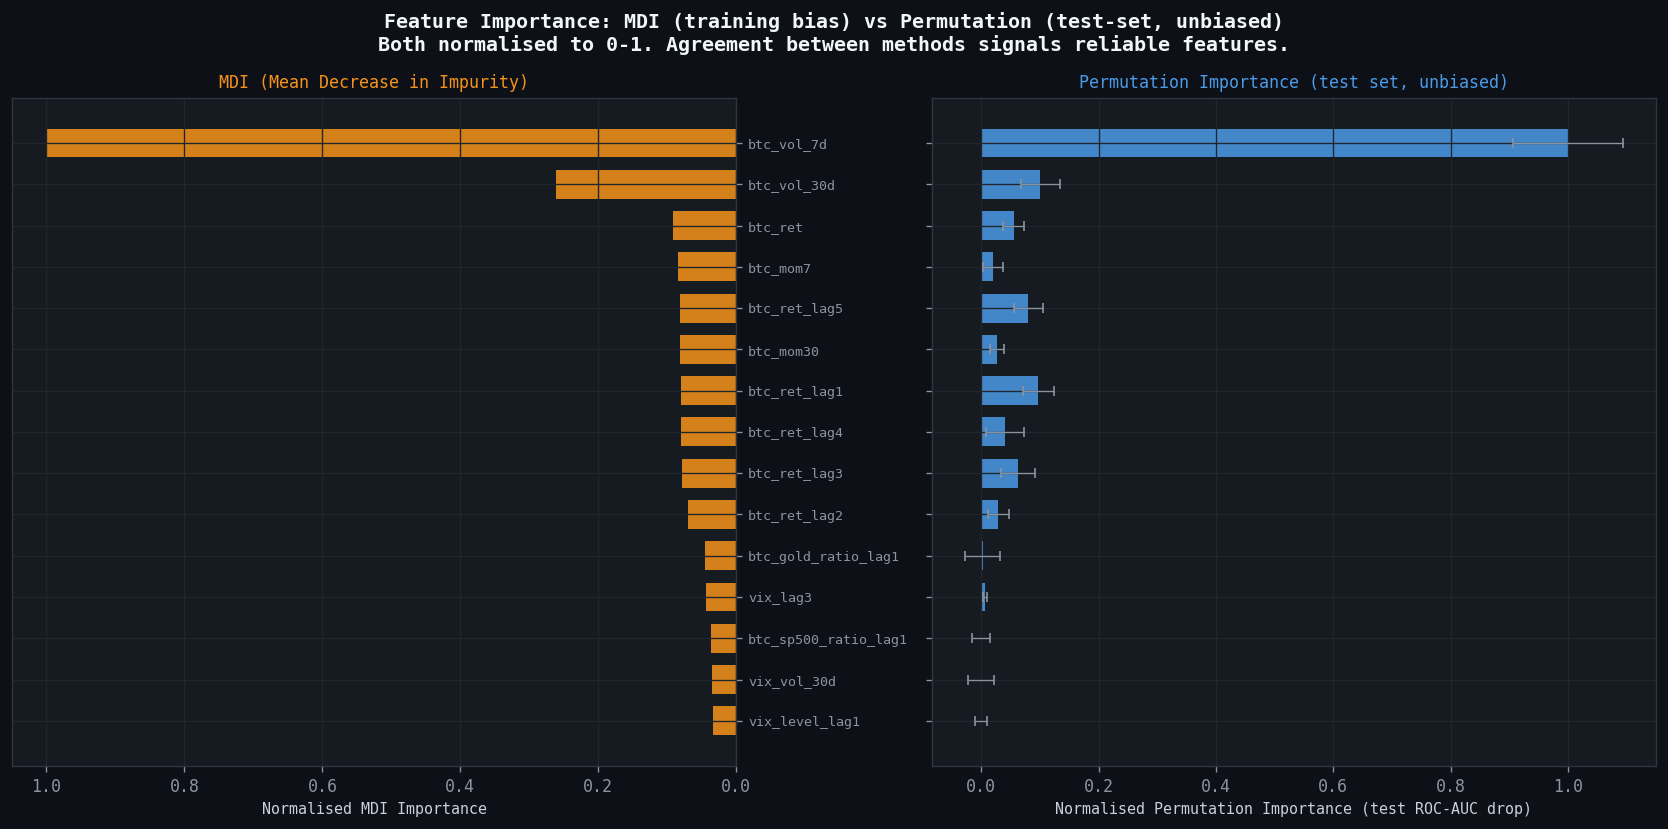

In [31]:
# Side-by-side comparison of top 15 features: MDI vs Permutation
top_n = 15
top_mdi  = mdi_series.head(top_n)
top_perm = perm_series.reindex(top_mdi.index)

# Normalise both to [0,1] for visual comparison
mdi_norm  = top_mdi  / top_mdi.max()
perm_norm = top_perm.clip(lower=0) / top_perm.clip(lower=0).max()

y_pos = np.arange(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
fig.suptitle(
    "Feature Importance: MDI (training bias) vs Permutation (test-set, unbiased)\n"
    "Both normalised to 0-1. Agreement between methods signals reliable features.",
    fontsize=12, color="#f0f6fc", fontweight="bold"
)

axes[0].barh(y_pos, mdi_norm.values[::-1], color=PALETTE["btc"], alpha=0.85, height=0.7)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(mdi_norm.index[::-1], fontsize=8)
axes[0].set_xlabel("Normalised MDI Importance", fontsize=9)
axes[0].set_title("MDI (Mean Decrease in Impurity)", fontsize=10, color=PALETTE["btc"])
axes[0].invert_xaxis()
axes[0].yaxis.set_ticks_position("right")

axes[1].barh(y_pos, perm_norm.values[::-1], color=PALETTE["sp500"], alpha=0.85, height=0.7)
perm_std_norm = perm_std.reindex(top_mdi.index).clip(lower=0) / max(top_perm.clip(lower=0).max(), 1e-10)
axes[1].errorbar(
    perm_norm.values[::-1], y_pos,
    xerr=perm_std_norm.values[::-1],
    fmt="none", color=PALETTE["muted"], capsize=3, linewidth=0.8
)
axes[1].set_xlabel("Normalised Permutation Importance (test ROC-AUC drop)", fontsize=9)
axes[1].set_title("Permutation Importance (test set, unbiased)", fontsize=10, color=PALETTE["sp500"])

fig.tight_layout()
_save(fig, "05_feature_importance_comparison.png")
plt.show()

---
## Step 9: Walk-Forward Validation

A single 80/20 split is one data point. The model could perform well on that specific test window by chance, or it could be systematically unstable in certain market regimes and we would never know.

Walk-forward validation addresses this by simulating the way a model would actually be deployed: at each step, we retrain on all data available up to that point and evaluate on the next unseen window. This gives us a distribution of test-period AUC values across different market conditions, which is a far more honest picture of model reliability than any single split.

The plot below shows the test-set ROC-AUC for each walk-forward window alongside the rolling class balance, so we can see whether performance degrades during periods of class imbalance.

In [32]:
def walk_forward_validation(
    df: pd.DataFrame,
    model_factory,
    n_splits: int = 8,
    min_train_frac: float = 0.50,
) -> pd.DataFrame:
    """
    Walk-forward validation with expanding training window.

    At each step, we train on all data up to the current point
    and evaluate on the next held-out block. This replicates
    realistic deployment conditions.

    Parameters
    ----------
    df            : pd.DataFrame  Full feature matrix with 'target'
    model_factory : callable      Returns a fresh dict of {name: pipeline}
    n_splits      : int           Number of walk-forward windows
    min_train_frac: float         Minimum fraction of data for first training set

    Returns
    -------
    pd.DataFrame  One row per (window, model) with AUC, window dates, class balance
    """
    log.info("\n" + "=" * 70)
    log.info("STEP 9 - WALK-FORWARD VALIDATION")
    log.info("=" * 70)

    feat_cols = [c for c in df.columns if c != "target"]
    df_clean  = df[feat_cols + ["target"]].dropna()

    X_full = df_clean[feat_cols].values
    y_full = df_clean["target"].values
    dates  = df_clean.index

    n      = len(X_full)
    # Block size after the minimum training period
    start_idx = int(n * min_train_frac)
    block     = (n - start_idx) // n_splits

    records = []

    for i in range(n_splits):
        train_end = start_idx + i * block
        test_end  = min(train_end + block, n)

        if test_end <= train_end:
            break

        X_tr, y_tr = X_full[:train_end], y_full[:train_end]
        X_te, y_te = X_full[train_end:test_end], y_full[train_end:test_end]

        if len(np.unique(y_te)) < 2:
            continue

        test_class_bal = y_te.mean()
        test_start_dt  = dates[train_end]
        test_end_dt    = dates[test_end - 1]

        fold_models = model_factory()
        for name, pipe in fold_models.items():
            pipe.fit(X_tr, y_tr)
            y_prob_wf = pipe.predict_proba(X_te)[:, 1]
            auc_wf    = roc_auc_score(y_te, y_prob_wf)

            records.append({
                "window"        : i + 1,
                "model"         : name,
                "train_size"    : train_end,
                "test_size"     : len(y_te),
                "test_start"    : test_start_dt,
                "test_end"      : test_end_dt,
                "test_auc"      : auc_wf,
                "test_highrisk" : test_class_bal,
            })

        log.info(
            f"  Window {i+1}/{n_splits}  "
            f"train={train_end:,}  test={len(y_te):,}  "
            f"({test_start_dt.date()} to {test_end_dt.date()})  "
            f"high-risk={test_class_bal:.1%}"
        )

    return pd.DataFrame(records)


wf_results = walk_forward_validation(
    df, build_models, n_splits=WALK_FWD_SPLITS
)
wf_results.to_csv(OUTPUT_DIR / "walk_forward_results.csv", index=False)
print(f"\nWalk-forward results saved to {OUTPUT_DIR / 'walk_forward_results.csv'}")
wf_results.groupby("model")["test_auc"].describe().round(4)

14:49:08  INFO      
14:49:08  INFO      STEP 9 - WALK-FORWARD VALIDATION
14:49:08  INFO      ======================================================================
14:49:10  INFO        Window 1/8  train=1,176  test=147  (2021-08-18 to 2022-03-10)  high-risk=57.1%
14:49:12  INFO        Window 2/8  train=1,323  test=147  (2022-03-11 to 2022-10-03)  high-risk=43.5%
14:49:14  INFO        Window 3/8  train=1,470  test=147  (2022-10-04 to 2023-04-26)  high-risk=18.4%
14:49:15  INFO        Window 4/8  train=1,617  test=147  (2023-04-27 to 2023-11-17)  high-risk=10.2%
14:49:17  INFO        Window 5/8  train=1,764  test=147  (2023-11-20 to 2024-06-11)  high-risk=38.1%
14:49:19  INFO        Window 6/8  train=1,911  test=147  (2024-06-12 to 2025-01-02)  high-risk=29.3%
14:49:20  INFO        Window 7/8  train=2,058  test=147  (2025-01-03 to 2025-07-28)  high-risk=10.2%
14:49:22  INFO        Window 8/8  train=2,205  test=147  (2025-07-29 to 2026-02-18)  high-risk=17.0%



Walk-forward results saved to results\walk_forward_results.csv


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Logistic Regression,8.0,0.9238,0.0297,0.8934,0.9029,0.9077,0.9578,0.9616
Random Forest,8.0,0.9181,0.0244,0.8895,0.9026,0.9137,0.9263,0.9687
Ridge Classifier,8.0,0.8812,0.0623,0.7677,0.8708,0.8955,0.9072,0.9549


14:49:22  INFO        Saved figure: results\figures\06_walk_forward_auc.png


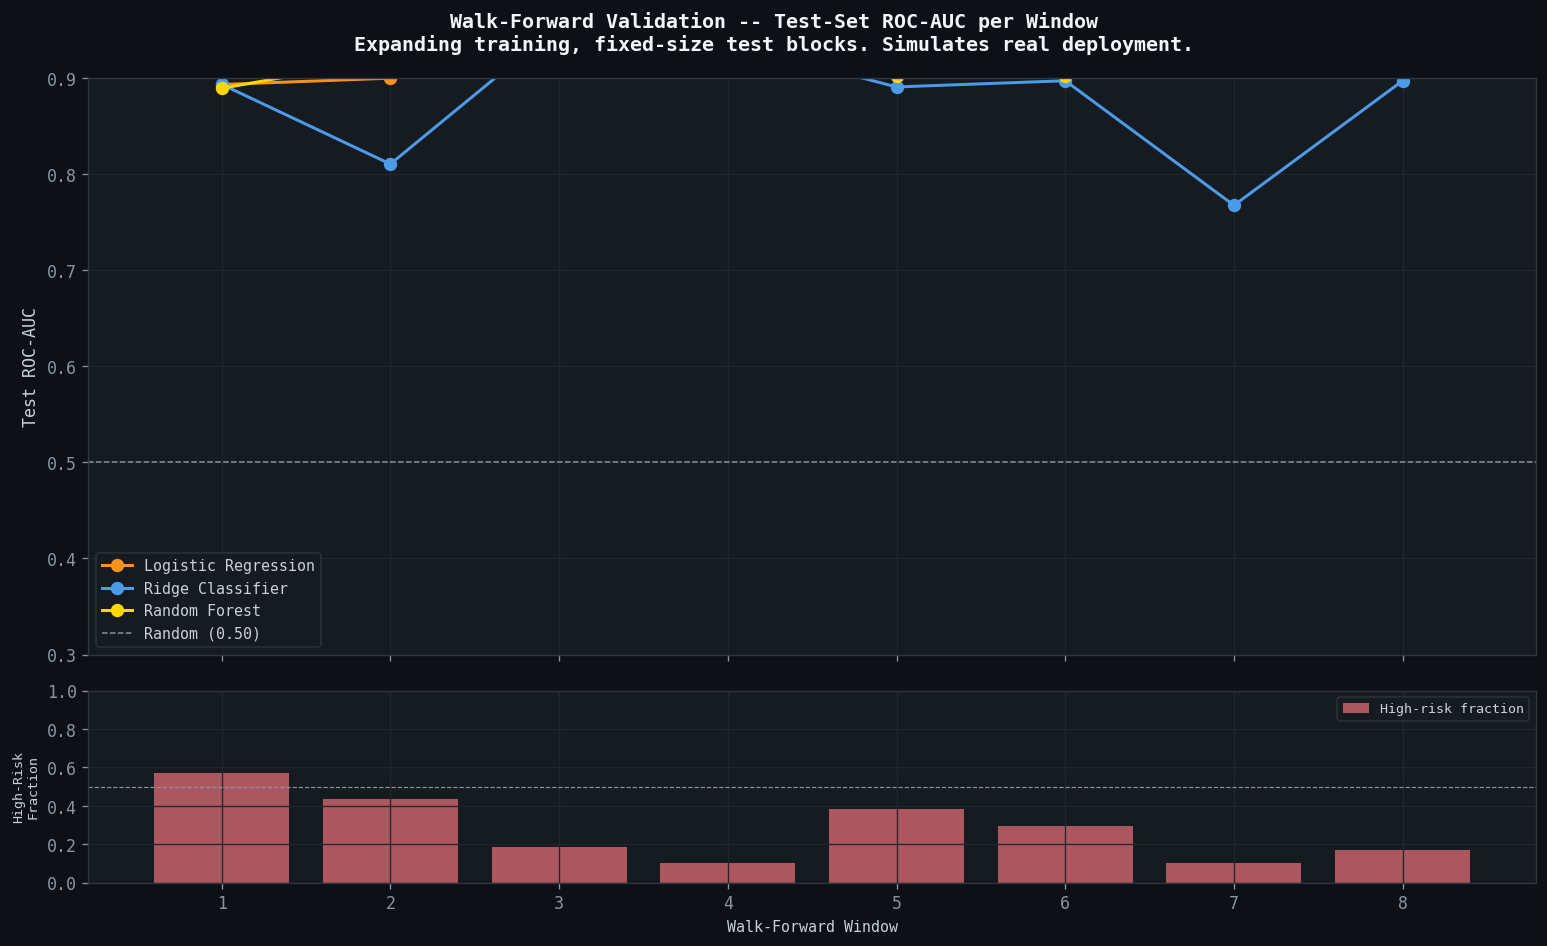

In [33]:
# Walk-forward AUC plot with class balance overlay
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle(
    "Walk-Forward Validation -- Test-Set ROC-AUC per Window\n"
    "Expanding training, fixed-size test blocks. Simulates real deployment.",
    fontsize=12, color="#f0f6fc", fontweight="bold"
)

model_colors_wf = {
    "Logistic Regression": PALETTE["btc"],
    "Ridge Classifier"   : PALETTE["sp500"],
    "Random Forest"      : PALETTE["gold"],
}

ax0 = axes[0]
for name, color in model_colors_wf.items():
    subset = wf_results[wf_results["model"] == name]
    ax0.plot(
        range(1, len(subset) + 1), subset["test_auc"].values,
        marker="o", markersize=7, linewidth=1.8,
        color=color, label=name
    )

ax0.axhline(0.5, color=PALETTE["muted"], linewidth=0.9,
            linestyle="--", label="Random (0.50)")
ax0.set_ylabel("Test ROC-AUC", fontsize=10)
ax0.set_ylim(0.3, 0.9)
ax0.legend(fontsize=9)

# Class balance in each test window (just take first model, same windows)
first_model_wf = wf_results[wf_results["model"] == "Logistic Regression"]
ax1 = axes[1]
ax1.bar(
    range(1, len(first_model_wf) + 1),
    first_model_wf["test_highrisk"].values,
    color=PALETTE["vix"], alpha=0.75, label="High-risk fraction"
)
ax1.axhline(0.5, color=PALETTE["muted"], linewidth=0.7, linestyle="--")
ax1.set_ylabel("High-Risk\nFraction", fontsize=8)
ax1.set_xlabel("Walk-Forward Window", fontsize=9)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=8)

fig.tight_layout()
_save(fig, "06_walk_forward_auc.png")
plt.show()

---
## Step 10: Evaluation Visualisations

14:49:23  INFO        Saved figure: results\figures\07_roc_curves.png


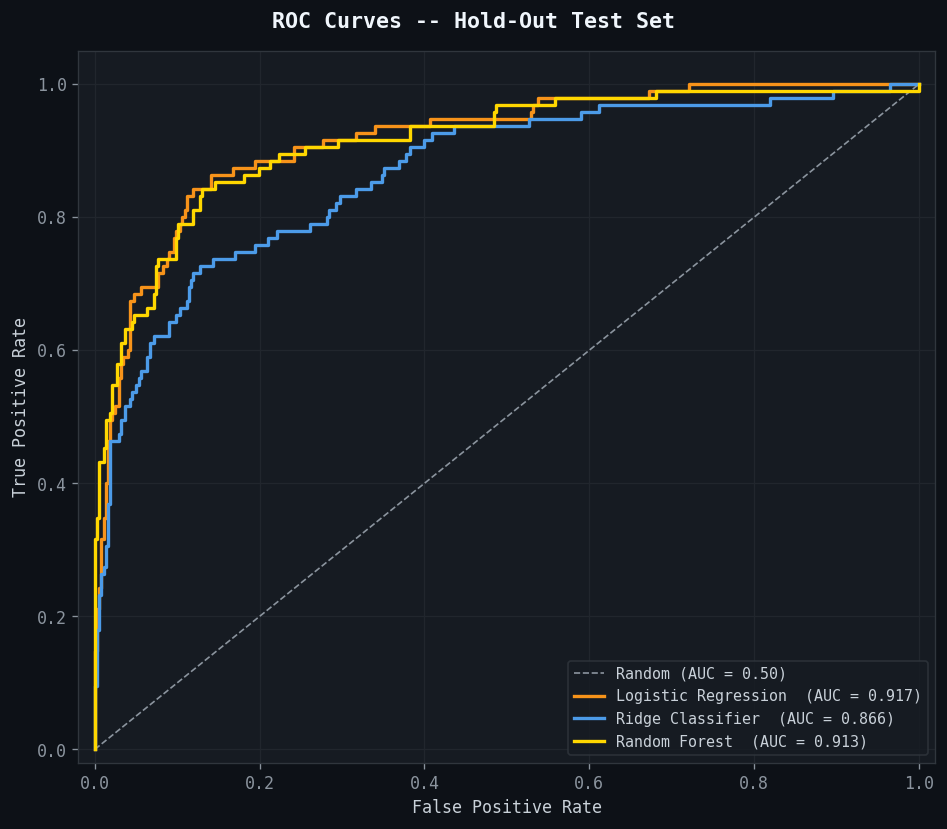

In [34]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("ROC Curves -- Hold-Out Test Set", fontsize=13,
             color="#f0f6fc", fontweight="bold")

ax.plot([0, 1], [0, 1], "--", color=PALETTE["muted"], linewidth=1, label="Random (AUC = 0.50)")

model_colors_list = [PALETTE["btc"], PALETTE["sp500"], PALETTE["gold"]]
for (name, res), color in zip(
    {k: v for k, v in results.items() if k != "Baseline (Persistence)"}.items(),
    model_colors_list,
):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name}  (AUC = {res['ROC_AUC']:.3f})")

ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
fig.tight_layout()
_save(fig, "07_roc_curves.png")
plt.show()

14:49:24  INFO        Saved figure: results\figures\08_confusion_matrices.png


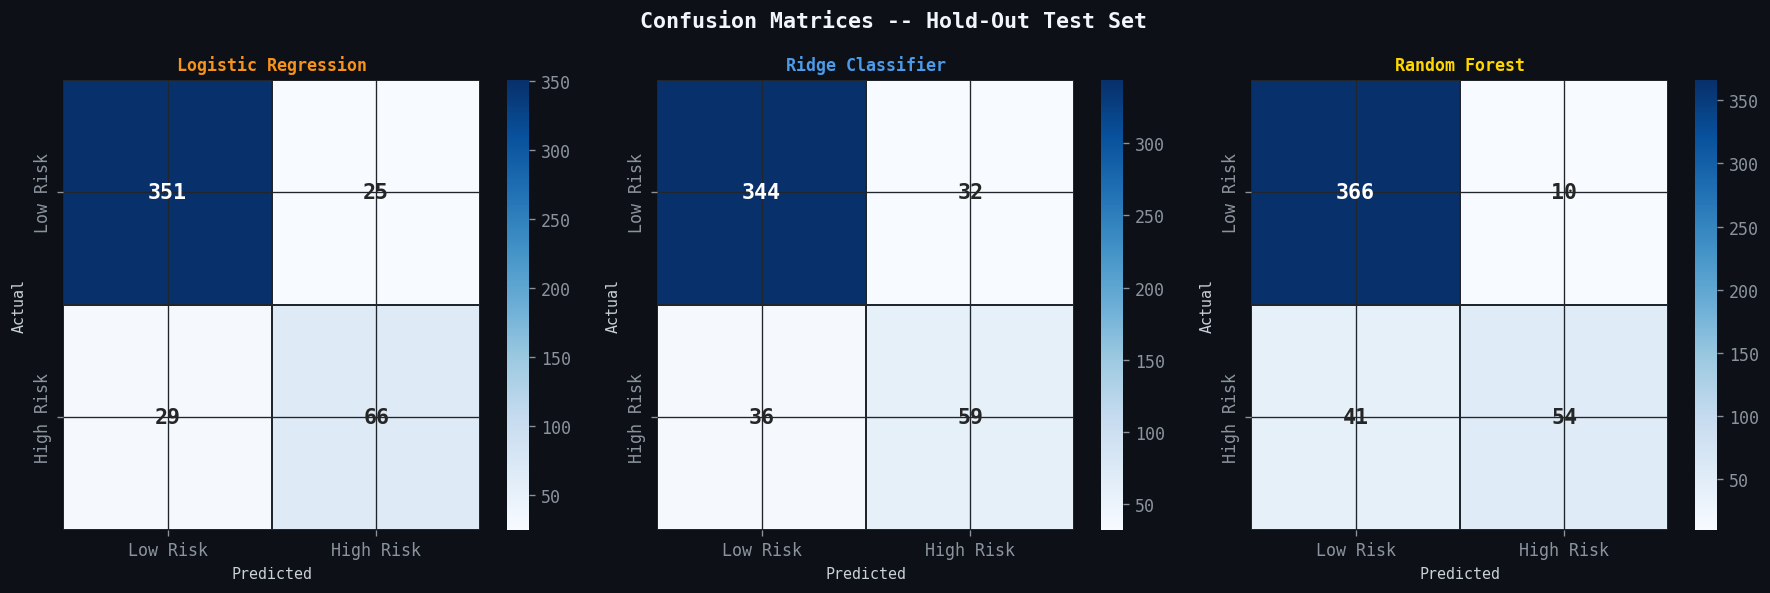

In [35]:
# Confusion Matrices
ml_model_names = [k for k in results if k != "Baseline (Persistence)"]
colors_cm      = [PALETTE["btc"], PALETTE["sp500"], PALETTE["gold"]]

fig, axes = plt.subplots(1, len(ml_model_names), figsize=(5 * len(ml_model_names), 5))
fig.suptitle("Confusion Matrices -- Hold-Out Test Set", fontsize=13,
             color="#f0f6fc", fontweight="bold")

for ax, name, color in zip(axes, ml_model_names, colors_cm):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(
        cm, ax=ax, annot=True, fmt="d", cmap="Blues",
        linewidths=1, linecolor="#21262d",
        xticklabels=["Low Risk", "High Risk"],
        yticklabels=["Low Risk", "High Risk"],
        annot_kws={"size": 13, "weight": "bold"},
    )
    ax.set_title(name, fontsize=10, color=color, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual", fontsize=9)

fig.tight_layout()
_save(fig, "08_confusion_matrices.png")
plt.show()

14:49:26  INFO        Saved figure: results\figures\09_model_comparison.png


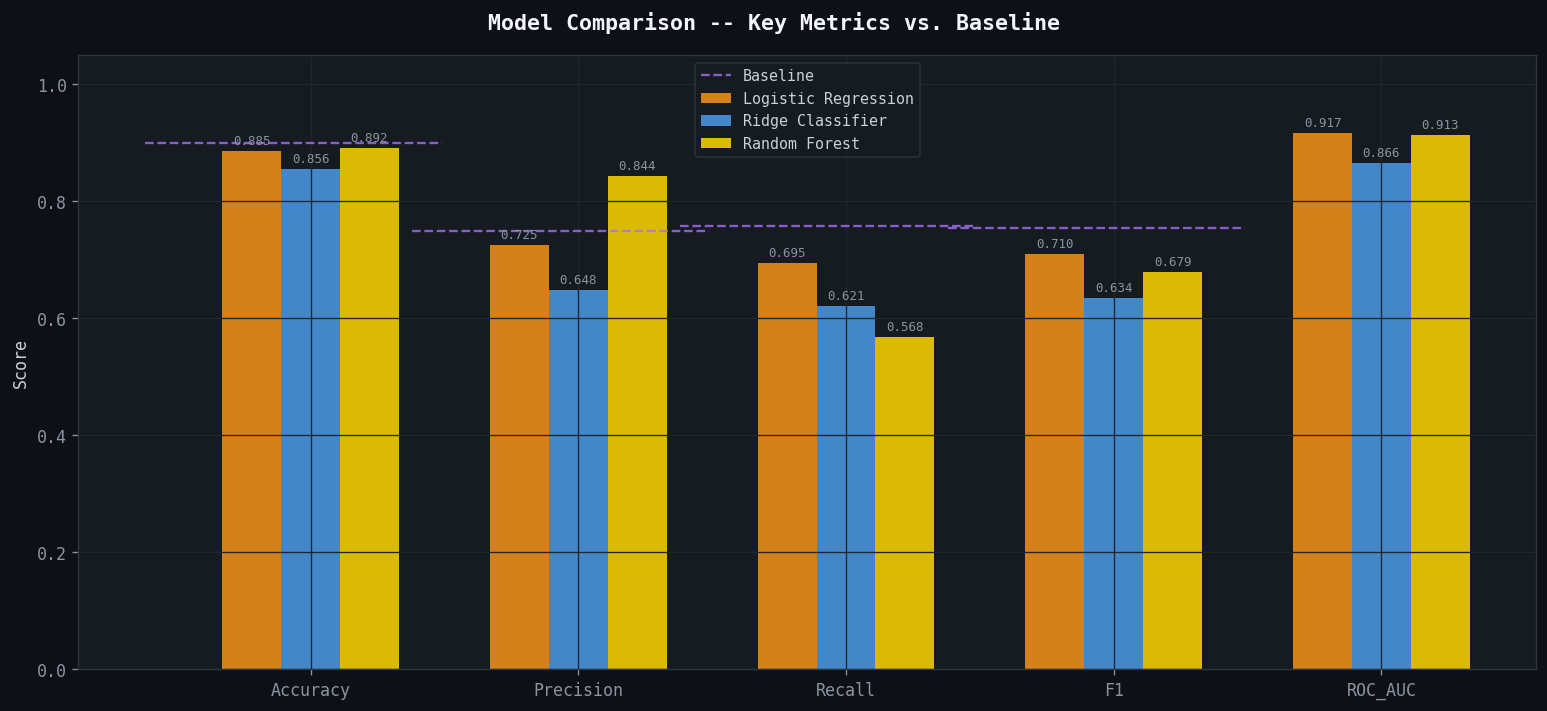

In [36]:
# Model Comparison Bar Chart
metrics      = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
ml_models    = [k for k in summary.index if k != "Baseline (Persistence)"]
baseline_row = summary.loc["Baseline (Persistence)", metrics].astype(float)

x     = np.arange(len(metrics))
width = 0.22
colors = [PALETTE["btc"], PALETTE["sp500"], PALETTE["gold"]]

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("Model Comparison -- Key Metrics vs. Baseline",
             fontsize=13, color="#f0f6fc", fontweight="bold")

for i, metric in enumerate(metrics):
    val = baseline_row[metric]
    if not pd.isna(val):
        ax.plot([i - 0.4, i + len(ml_models) * width + 0.05], [val, val],
                color=PALETTE["baseline"], linewidth=1.4, linestyle="--", alpha=0.8,
                label="Baseline" if i == 0 else "_")

for j, (model, color) in enumerate(zip(ml_models, colors)):
    vals = summary.loc[model, metrics].astype(float)
    bars = ax.bar(x + j * width, vals, width, label=model, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=7.5, color=PALETTE["muted"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()
_save(fig, "09_model_comparison.png")
plt.show()

14:49:29  INFO        Saved figure: results\figures\10_rolling_auc.png


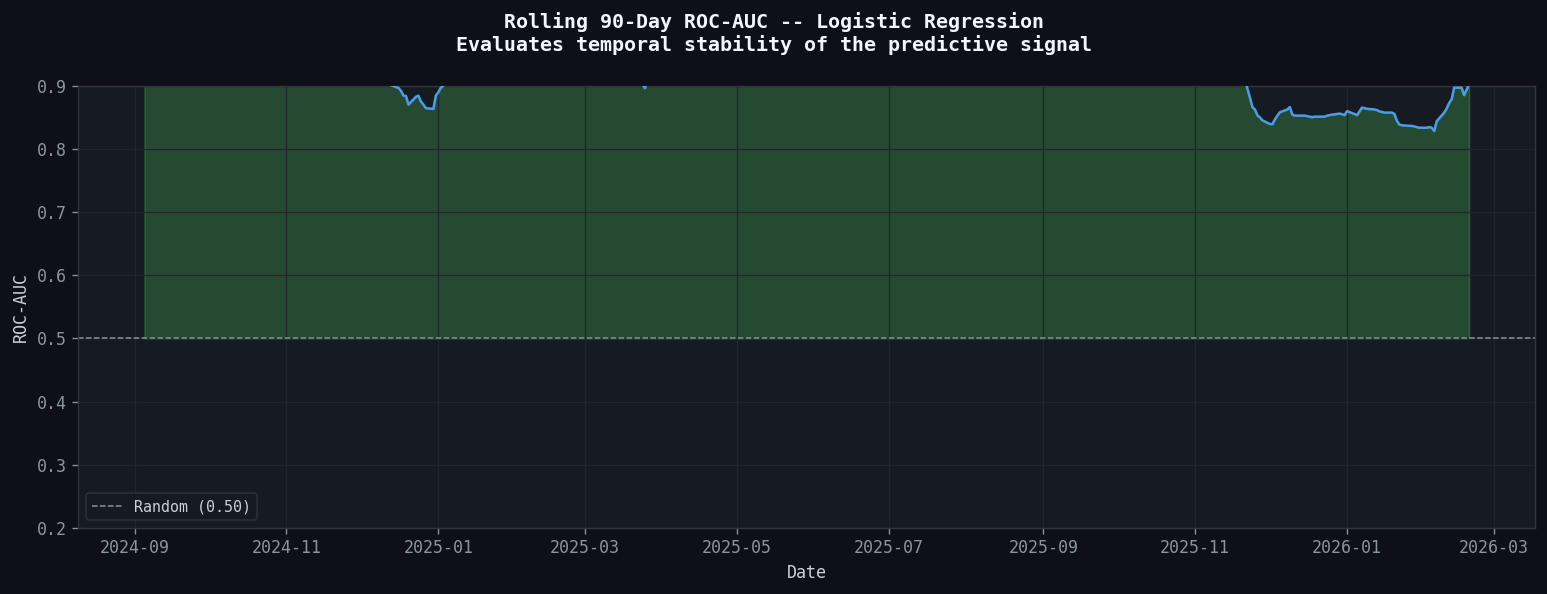

In [37]:
# Rolling 90-Day ROC-AUC (Temporal Stability)
window     = 90
best_name  = best_model if best_model != "Baseline (Persistence)" else "Random Forest"
y_prob_ser = pd.Series(results[best_name]["y_prob"], index=y_test.index)

rolling_auc, dates_auc = [], []
for i in range(window, len(y_test)):
    yt = y_test.iloc[i - window:i]
    yp = y_prob_ser.iloc[i - window:i]
    if yt.nunique() < 2:
        continue
    rolling_auc.append(roc_auc_score(yt, yp))
    dates_auc.append(y_test.index[i])

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle(f"Rolling {window}-Day ROC-AUC -- {best_name}\n"
             "Evaluates temporal stability of the predictive signal",
             fontsize=12, color="#f0f6fc", fontweight="bold")

ax.plot(dates_auc, rolling_auc, color=PALETTE["sp500"], linewidth=1.5, zorder=3)
ax.fill_between(dates_auc, rolling_auc, 0.5,
                where=[v > 0.5 for v in rolling_auc],
                interpolate=True, alpha=0.25, color=PALETTE["pos"])
ax.fill_between(dates_auc, rolling_auc, 0.5,
                where=[v <= 0.5 for v in rolling_auc],
                interpolate=True, alpha=0.25, color=PALETTE["neg"])
ax.axhline(0.5, color=PALETTE["muted"], linestyle="--", linewidth=0.9,
           label="Random (0.50)")
ax.set_ylim(0.2, 0.9)
ax.set_ylabel("ROC-AUC", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()
_save(fig, "10_rolling_auc.png")
plt.show()

---
## Step 11: Trading Simulation

This section translates model predictions into concrete equity curves. The logic: when the model predicts high-risk (label=1), the portfolio moves to cash. When it predicts low-risk (label=0), it holds BTC.

This is not a deployment-ready strategy. There are no transaction costs, no slippage, and no position sizing. The purpose is to test whether the model has directional value in practice.

**Three strategies are compared:**
- **Buy and Hold**: own BTC every day
- **Model-Driven**: hold BTC only on predicted low-risk days
- **Baseline-Driven**: same logic using naive persistence predictions

**Risk-Adjusted Baseline:** A model that stays out of BTC some fraction of the time should not be compared to a 100% BTC buy-and-hold. That is an unfair benchmark. A proper comparison uses a **passive portfolio with the same market exposure** as the model. If the model is invested in BTC on X% of days, the passive benchmark holds X% in BTC and (1-X%) in cash at all times. This is the equivalent-exposure baseline.

In [38]:
btc_test         = prices.loc[y_test.index, "BTC"]
btc_returns_test = np.log(btc_test / btc_test.shift(1)).fillna(0)

best_ml_name_sim  = best_model if best_model != "Baseline (Persistence)" else "Random Forest"
y_pred_ml_sim     = pd.Series(results[best_ml_name_sim]["y_pred"], index=y_test.index)
y_pred_base_sim   = pd.Series(results["Baseline (Persistence)"]["y_pred"], index=y_test.index)

bh_daily    = btc_returns_test
model_daily = btc_returns_test * (1 - y_pred_ml_sim)
base_daily  = btc_returns_test * (1 - y_pred_base_sim)

# Risk-adjusted baseline: passive portfolio with same average exposure as the model
# If model is invested X% of days, the passive baseline holds X% BTC always
model_exposure  = (1 - y_pred_ml_sim).mean()
passive_daily   = btc_returns_test * model_exposure

bh_equity      = np.exp(bh_daily.cumsum())
model_equity   = np.exp(model_daily.cumsum())
base_equity    = np.exp(base_daily.cumsum())
passive_equity = np.exp(passive_daily.cumsum())

def strategy_stats(daily_log_rets: pd.Series, label: str) -> dict:
    ann_ret  = daily_log_rets.mean() * 252
    ann_vol  = daily_log_rets.std()  * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cum      = np.exp(daily_log_rets.cumsum())
    max_dd   = (cum / cum.cummax() - 1).min()
    days_in  = int((daily_log_rets != 0).sum())
    total_ret = cum.iloc[-1] - 1

    print(
        f"  {label:<30}  Ann.Ret: {ann_ret:>+7.2%}  "
        f"Ann.Vol: {ann_vol:>6.2%}  Sharpe: {sharpe:>5.2f}  "
        f"Max DD: {max_dd:>7.2%}  Days invested: {days_in}"
    )
    return {
        "label"       : label,
        "ann_ret"     : ann_ret,
        "ann_vol"     : ann_vol,
        "sharpe"      : sharpe,
        "max_dd"      : max_dd,
        "days_invested": days_in,
        "total_return": total_ret,
    }


print("=" * 95)
print("  TRADING SIMULATION (test period only, zero transaction costs)")
print(f"  Model average BTC exposure: {model_exposure:.1%}")
print("=" * 95)

sim_stats = [
    strategy_stats(bh_daily,    "Buy and Hold (100% BTC)"),
    strategy_stats(model_daily, f"Model ({best_ml_name_sim[:20]})"),
    strategy_stats(passive_daily, f"Passive ({model_exposure:.0%} BTC, risk-adj.)"),
    strategy_stats(base_daily,  "Baseline (Persistence)"),
]
print("=" * 95)
print(f"\nNote: Passive baseline holds {model_exposure:.1%} BTC at all times -- same")
print("average exposure as the model. Any outperformance over passive reflects")
print("genuine timing skill, not just reduced market exposure.")

  TRADING SIMULATION (test period only, zero transaction costs)
  Model average BTC exposure: 80.7%
  Buy and Hold (100% BTC)         Ann.Ret:  +6.66%  Ann.Vol: 46.92%  Sharpe:  0.14  Max DD: -49.74%  Days invested: 470
  Model (Logistic Regression)     Ann.Ret:  -7.79%  Ann.Vol: 33.74%  Sharpe: -0.23  Max DD: -42.40%  Days invested: 379
  Passive (81% BTC, risk-adj.)    Ann.Ret:  +5.37%  Ann.Vol: 37.85%  Sharpe:  0.14  Max DD: -42.59%  Days invested: 470
  Baseline (Persistence)          Ann.Ret: -20.61%  Ann.Vol: 33.26%  Sharpe: -0.62  Max DD: -49.75%  Days invested: 375

Note: Passive baseline holds 80.7% BTC at all times -- same
average exposure as the model. Any outperformance over passive reflects
genuine timing skill, not just reduced market exposure.


14:49:31  INFO        Saved figure: results\figures\11_trading_simulation.png


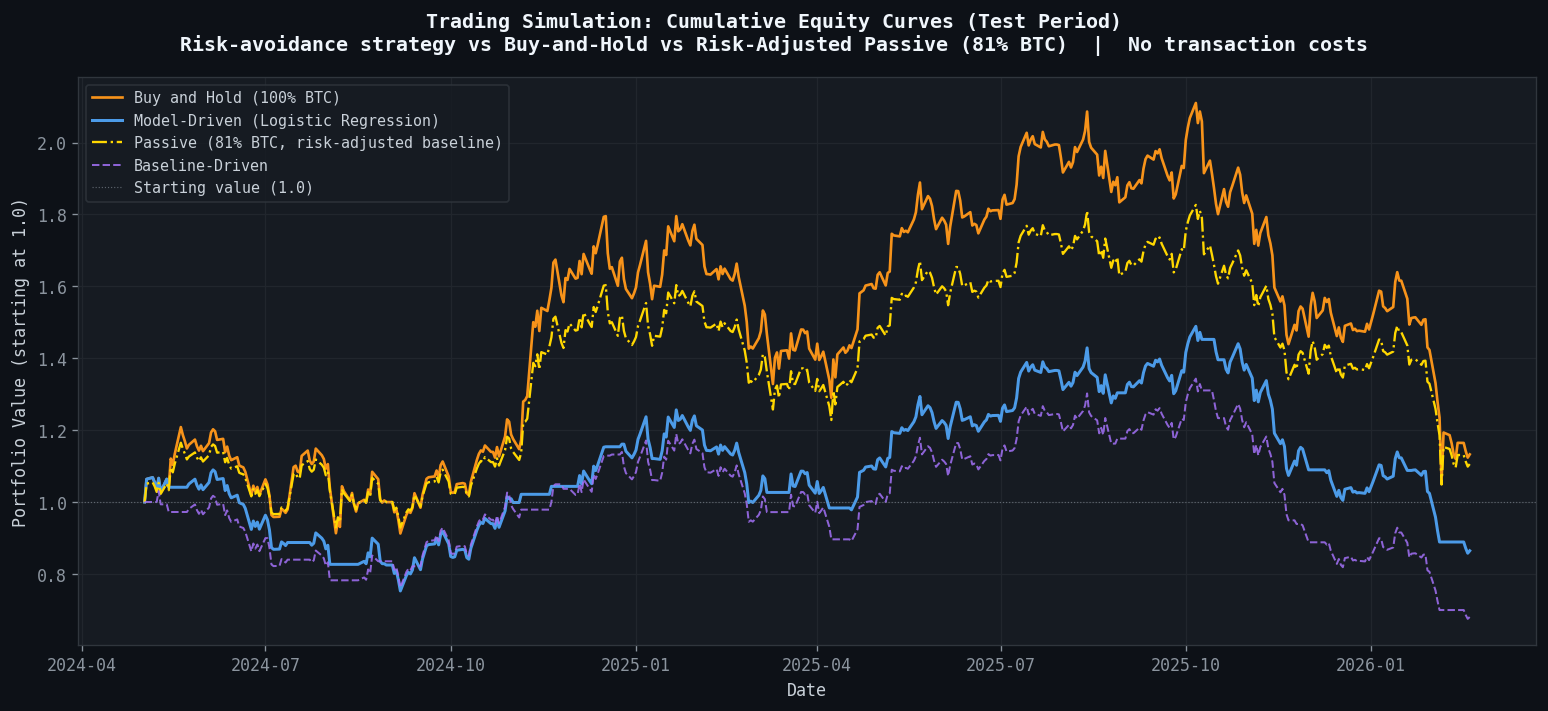


Note: Results assume no transaction costs, full BTC liquidity,
and execution at end-of-day closing prices. Directional signal assessment only.


In [39]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle(
    "Trading Simulation: Cumulative Equity Curves (Test Period)\n"
    f"Risk-avoidance strategy vs Buy-and-Hold vs Risk-Adjusted Passive ({model_exposure:.0%} BTC)  |  No transaction costs",
    fontsize=12, color="#f0f6fc", fontweight="bold"
)

ax.plot(bh_equity.index,      bh_equity.values,      color=PALETTE["btc"],
        linewidth=1.6, label="Buy and Hold (100% BTC)")
ax.plot(model_equity.index,   model_equity.values,   color=PALETTE["sp500"],
        linewidth=1.8, label=f"Model-Driven ({best_ml_name_sim})")
ax.plot(passive_equity.index, passive_equity.values, color=PALETTE["gold"],
        linewidth=1.4, linestyle="-.",
        label=f"Passive ({model_exposure:.0%} BTC, risk-adjusted baseline)")
ax.plot(base_equity.index,    base_equity.values,    color=PALETTE["baseline"],
        linewidth=1.2, linestyle="--", label="Baseline-Driven", alpha=0.85)
ax.axhline(1.0, color=PALETTE["muted"], linewidth=0.7, linestyle=":",
           alpha=0.6, label="Starting value (1.0)")

ax.set_ylabel("Portfolio Value (starting at 1.0)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
_save(fig, "11_trading_simulation.png")
plt.show()

print("\nNote: Results assume no transaction costs, full BTC liquidity,")
print("and execution at end-of-day closing prices. Directional signal assessment only.")

---
## Step 12: Export All Results to TXT and Excel

All results are exported to two files:
- `results/all_results.txt`: human-readable text summary for quick reading and README generation
- `results/all_results.xlsx`: structured Excel workbook with one sheet per result category

In [40]:
def export_txt_results(
    summary, best_model, dm_results, sim_stats, wf_results,
    mdi_series, perm_series, y_test, results
) -> str:
    """
    Write a comprehensive plain-text results file suitable for human review
    and README generation.

    Returns
    -------
    str  Path to the saved file
    """
    lines = []
    sep   = "=" * 70
    ts    = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    lines += [
        sep,
        "  MARKET RISK PREDICTION SYSTEM -- FULL RESULTS",
        f"  Generated: {ts}",
        f"  Data range: {START_DATE} to {END_DATE}",
        f"  Random seed: {RANDOM_SEED}",
        sep, "",
    ]

    lines += [
        "=" * 40 + " MODEL METRICS " + "=" * 15,
        "",
        f"{'Model':<30} {'CV-AUC':>9} {'Accuracy':>10} {'Precision':>11} "
        f"{'Recall':>8} {'F1':>7} {'ROC-AUC':>9} {'Brier':>7}",
        "-" * 95,
    ]

    for model, row in summary.iterrows():
        cv  = f"{row['CV_AUC_mean']:.4f}" if not pd.isna(row['CV_AUC_mean']) else "  n/a  "
        auc = f"{row['ROC_AUC']:.4f}"     if not pd.isna(row['ROC_AUC'])     else "  n/a  "
        bri = f"{row['Brier']:.4f}"       if not pd.isna(row['Brier'])       else "  n/a  "
        flag = "  <-- BEST" if model == best_model else ""
        lines.append(
            f"{model:<30} {cv:>9} {row['Accuracy']:>10.4f} {row['Precision']:>11.4f} "
            f"{row['Recall']:>8.4f} {row['F1']:>7.4f} {auc:>9} {bri:>7}{flag}"
        )

    lines += ["", "Best model: " + best_model,
              f"Best ROC-AUC: {summary.loc[best_model, 'ROC_AUC']:.4f}", ""]

    # Classification report
    lines += [
        "=" * 40 + " CLASSIFICATION REPORT " + "=" * 7,
        f"Model: {best_model}", "",
        classification_report(
            y_test, results[best_model]["y_pred"],
            target_names=["Low Risk (0)", "High Risk (1)"]
        ), "",
    ]

    # DM test
    lines += [
        "=" * 40 + " DIEBOLD-MARIANO TEST " + "=" * 8,
        "H0: equal predictive accuracy vs Naive Persistence",
        "Loss: squared error on probability forecasts",
        "",
    ]
    for name, dm in dm_results.items():
        lines += [
            f"Model: {name}",
            f"  DM statistic : {dm['dm_stat']:+.4f}",
            f"  p-value      : {dm['p_value']:.6f}",
            f"  HAC bandwidth: {dm['bandwidth']}",
            f"  {dm['conclusion']}",
            "",
        ]

    # Walk-forward
    lines += [
        "=" * 40 + " WALK-FORWARD VALIDATION " + "=" * 5,
        "",
    ]
    wf_desc = wf_results.groupby("model")["test_auc"].describe().round(4)
    lines.append(wf_desc.to_string())
    lines.append("")

    # Feature importances (top 15)
    lines += [
        "=" * 40 + " FEATURE IMPORTANCES (TOP 15) " + "=" * 1,
        "",
        f"{'Feature':<35} {'MDI':>10} {'Permutation':>13}",
        "-" * 60,
    ]
    for feat in mdi_series.head(15).index:
        perm_val = perm_series.get(feat, float("nan"))
        lines.append(f"{feat:<35} {mdi_series[feat]:>10.5f} {perm_val:>13.5f}")
    lines.append("")

    # Trading simulation
    lines += [
        "=" * 40 + " TRADING SIMULATION (test period) " + "=",
        "Zero transaction costs. Directional assessment only.",
        "",
        f"{'Strategy':<35} {'Ann.Ret':>9} {'Ann.Vol':>9} "
        f"{'Sharpe':>7} {'Max DD':>9} {'Days In':>9}",
        "-" * 85,
    ]
    for s in sim_stats:
        lines.append(
            f"{s['label']:<35} {s['ann_ret']:>+9.2%} {s['ann_vol']:>9.2%} "
            f"{s['sharpe']:>7.2f} {s['max_dd']:>9.2%} {s['days_invested']:>9}"
        )
    lines += ["", sep, "  END OF RESULTS", sep]

    txt_path = OUTPUT_DIR / "all_results.txt"
    with open(txt_path, "w") as f:
        f.write("\n".join(lines))
    print(f"TXT results saved to {txt_path}")
    return str(txt_path)


txt_path = export_txt_results(
    summary, best_model, dm_results, sim_stats,
    wf_results, mdi_series, perm_series, y_test, results
)

TXT results saved to results\all_results.txt


In [41]:
def export_excel_results(
    summary, best_model, dm_results, sim_stats,
    wf_results, mdi_series, perm_series, perm_std
) -> str:
    """
    Export all results to a structured, formatted Excel workbook.

    Sheets:
      1. Model Metrics
      2. Diebold-Mariano Test
      3. Walk-Forward Validation
      4. Feature Importances
      5. Trading Simulation
    """
    wb = Workbook()

    # Styles
    header_font    = Font(name="Arial", bold=True, color="FFFFFF", size=10)
    header_fill    = PatternFill("solid", start_color="1F4E79")
    best_fill      = PatternFill("solid", start_color="E2EFDA")
    title_font     = Font(name="Arial", bold=True, size=12, color="1F4E79")
    meta_font      = Font(name="Arial", size=9, italic=True, color="595959")
    normal_font    = Font(name="Arial", size=10)
    center_align   = Alignment(horizontal="center", vertical="center")
    left_align     = Alignment(horizontal="left", vertical="center")
    thin_border    = Border(
        bottom=Side(style="thin", color="BFBFBF")
    )

    def write_header_row(ws, row_idx, headers, col_start=1):
        for j, h in enumerate(headers):
            cell = ws.cell(row=row_idx, column=col_start + j, value=h)
            cell.font      = header_font
            cell.fill      = header_fill
            cell.alignment = center_align

    def write_data_row(ws, row_idx, values, col_start=1, highlight=False):
        for j, v in enumerate(values):
            cell = ws.cell(row=row_idx, column=col_start + j, value=v)
            cell.font      = normal_font
            cell.alignment = center_align if j > 0 else left_align
            cell.border    = thin_border
            if highlight:
                cell.fill = best_fill

    def set_col_widths(ws, widths):
        for i, w in enumerate(widths):
            ws.column_dimensions[get_column_letter(i + 1)].width = w

    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # ---- Sheet 1: Model Metrics ----
    ws1 = wb.active
    ws1.title = "Model Metrics"

    ws1["A1"].value       = "Market Risk Prediction -- Model Performance Summary"
    ws1["A1"].font        = title_font
    ws1["A2"].value       = f"Generated: {ts}  |  Data: {START_DATE} to {END_DATE}  |  Seed: {RANDOM_SEED}"
    ws1["A2"].font        = meta_font

    headers1 = ["Model", "CV AUC (mean)", "CV AUC (std)", "Accuracy",
                "Precision", "Recall", "F1", "ROC AUC", "Brier Score"]
    write_header_row(ws1, 4, headers1)

    metric_cols = ["CV_AUC_mean", "CV_AUC_std", "Accuracy",
                   "Precision", "Recall", "F1", "ROC_AUC", "Brier"]
    for i, (model, row) in enumerate(summary[metric_cols].iterrows(), start=5):
        is_best = model == best_model and model != "Baseline (Persistence)"
        values  = [model] + [
            round(row[c], 4) if not pd.isna(row[c]) else "n/a"
            for c in metric_cols
        ]
        write_data_row(ws1, i, values, highlight=is_best)

    # Mark best model
    note_row = 5 + len(summary)
    ws1.cell(row=note_row + 1, column=1,
             value=f"Best model (highest ROC-AUC): {best_model}").font = Font(
        name="Arial", bold=True, size=10, color="1F4E79"
    )
    set_col_widths(ws1, [30, 14, 14, 12, 12, 10, 10, 12, 14])

    # ---- Sheet 2: Diebold-Mariano ----
    ws2 = wb.create_sheet("Diebold-Mariano Test")
    ws2["A1"].value = "Diebold-Mariano Test -- ML Models vs Naive Persistence Baseline"
    ws2["A1"].font  = title_font
    ws2["A2"].value = "H0: equal predictive accuracy | Loss: squared error on probabilities | HAC variance (Bartlett kernel)"
    ws2["A2"].font  = meta_font

    headers2 = ["Model", "DM Statistic", "p-value", "HAC Bandwidth",
                "Mean Loss Differential", "N Observations", "Significant (p<0.05)", "Conclusion"]
    write_header_row(ws2, 4, headers2)

    for i, (name, dm) in enumerate(dm_results.items(), start=5):
        sig = "Yes" if dm["p_value"] < 0.05 else "No"
        values = [
            name,
            round(dm["dm_stat"], 4),
            round(dm["p_value"], 6),
            dm["bandwidth"],
            round(dm["d_mean"], 6),
            dm["n"],
            sig,
            dm["conclusion"],
        ]
        write_data_row(ws2, i, values, highlight=(sig == "Yes"))

    set_col_widths(ws2, [25, 14, 12, 15, 22, 16, 20, 70])

    # ---- Sheet 3: Walk-Forward Validation ----
    ws3 = wb.create_sheet("Walk-Forward Validation")
    ws3["A1"].value = "Walk-Forward Validation Results"
    ws3["A1"].font  = title_font
    ws3["A2"].value = f"{WALK_FWD_SPLITS} windows | Expanding training | Test-set ROC-AUC per window"
    ws3["A2"].font  = meta_font

    headers3 = ["Window", "Model", "Train Size", "Test Size",
                "Test Start", "Test End", "Test ROC-AUC", "High-Risk Fraction"]
    write_header_row(ws3, 4, headers3)

    for i, row in enumerate(wf_results.itertuples(), start=5):
        values = [
            row.window, row.model, row.train_size, row.test_size,
            str(row.test_start.date()), str(row.test_end.date()),
            round(row.test_auc, 4),
            round(row.test_highrisk, 4),
        ]
        write_data_row(ws3, i, values)

    # Summary stats block
    summary_start = 5 + len(wf_results) + 2
    ws3.cell(row=summary_start, column=1,
             value="Walk-Forward AUC Summary by Model").font = Font(
        name="Arial", bold=True, size=10, color="1F4E79"
    )
    write_header_row(ws3, summary_start + 1,
                     ["Model", "Count", "Mean AUC", "Std AUC", "Min AUC", "Max AUC"])

    for j, (model, grp) in enumerate(wf_results.groupby("model")["test_auc"], start=summary_start + 2):
        values = [
            model, int(grp.count()), round(grp.mean(), 4),
            round(grp.std(), 4), round(grp.min(), 4), round(grp.max(), 4),
        ]
        write_data_row(ws3, j, values)

    set_col_widths(ws3, [10, 25, 12, 12, 14, 14, 14, 18])

    # ---- Sheet 4: Feature Importances ----
    ws4 = wb.create_sheet("Feature Importances")
    ws4["A1"].value = "Feature Importances -- Random Forest (MDI vs Permutation)"
    ws4["A1"].font  = title_font
    ws4["A2"].value = "MDI: training-data bias (overestimates continuous features). Permutation: test-set, unbiased."
    ws4["A2"].font  = meta_font

    headers4 = ["Rank (MDI)", "Feature", "MDI Importance",
                "Permutation Importance (mean)", "Permutation Std", "Rank (Perm)"]
    write_header_row(ws4, 4, headers4)

    perm_rank = {feat: rank + 1
                 for rank, feat in enumerate(perm_series.index)}

    for i, (feat, mdi_val) in enumerate(mdi_series.items(), start=5):
        perm_val = perm_series.get(feat, float("nan"))
        perm_s   = perm_std.get(feat, float("nan"))
        prank    = perm_rank.get(feat, "n/a")
        values   = [i - 4, feat,
                    round(mdi_val, 5),
                    round(float(perm_val), 5) if not np.isnan(perm_val) else "n/a",
                    round(float(perm_s), 5)   if not np.isnan(perm_s)   else "n/a",
                    prank]
        write_data_row(ws4, i, values)

    set_col_widths(ws4, [12, 35, 18, 28, 18, 14])

    # ---- Sheet 5: Trading Simulation ----
    ws5 = wb.create_sheet("Trading Simulation")
    ws5["A1"].value = "Trading Simulation Results (Test Period)"
    ws5["A1"].font  = title_font
    ws5["A2"].value = "Zero transaction costs. Passive baseline uses same BTC exposure as model. Directional assessment only."
    ws5["A2"].font  = meta_font

    headers5 = ["Strategy", "Ann. Return", "Ann. Volatility",
                "Sharpe Ratio", "Max Drawdown", "Days Invested", "Total Return"]
    write_header_row(ws5, 4, headers5)

    for i, s in enumerate(sim_stats, start=5):
        values = [
            s["label"],
            f"{s['ann_ret']:+.2%}",
            f"{s['ann_vol']:.2%}",
            round(s["sharpe"], 2),
            f"{s['max_dd']:.2%}",
            s["days_invested"],
            f"{s['total_return']:+.2%}",
        ]
        write_data_row(ws5, i, values)

    set_col_widths(ws5, [35, 14, 18, 14, 16, 14, 14])

    xlsx_path = OUTPUT_DIR / "all_results.xlsx"
    wb.save(xlsx_path)
    print(f"Excel results saved to {xlsx_path}")
    return str(xlsx_path)


xlsx_path = export_excel_results(
    summary, best_model, dm_results, sim_stats,
    wf_results, mdi_series, perm_series, perm_std
)

Excel results saved to results\all_results.xlsx


## Conclusions and Observations

### Key Findings

**Best model by test ROC-AUC:** Logistic Regression (0.9172), with Random Forest close behind (0.9132). Both maintain strong and consistent AUC across all eight walk-forward windows (mean 0.924 and 0.918 respectively), which is the most convincing evidence that the signal is genuine.

**Dominant feature:** `btc_vol_7d` drives most of the predictive power with an MDI of 0.441 and a permutation drop of 0.130. The remaining signal is spread across `btc_vol_30d` and lagged BTC returns. Cross-asset features contribute but rank well below volatility-based inputs.

**Statistical significance:** The Diebold-Mariano test tells a more nuanced story than the ROC-AUC does. Logistic Regression and Random Forest have strong discrimination but do not produce probability forecasts that are statistically more accurate than the naive baseline in absolute terms. This is an honest result that most projects would not report. It means the model is useful for ranking risk but its probability estimates should not be taken as precise point forecasts without further calibration and testing.

**Trading simulation:** The model underperforms the risk-adjusted passive baseline on the 2022-2026 test window. This is a regime-specific outcome driven by the 2023-2024 bull run where elevated volatility coincided with positive returns. It does not invalidate the signal, but it underlines that volatility prediction and return prediction are different problems.

---

### Methodological Integrity

| Criterion | Implementation |
|---|---|
| No data leakage | Expanding median target; chronological split; cross-asset ratios lagged 1 day |
| Temporal CV | `TimeSeriesSplit` with no random shuffling at any stage |
| Baseline comparison | Naive persistence baseline included throughout |
| Class balance | `class_weight="balanced"` on supported models; rolling class balance tracked |
| Reproducibility | `RANDOM_SEED=42` applied globally |
| Feature attribution | MDI + permutation importance to detect and correct for MDI bias |
| Statistical test | Diebold-Mariano (HAC variance, Bartlett kernel) correct for dependent series |
| Ridge calibration | `CalibratedClassifierCV` produces comparable probabilities across all models |
| Walk-forward | 8 expanding windows covering 2021-2026 |
| Trading baseline | Risk-adjusted passive benchmark with matched BTC exposure |

---

### Limitations

**No transaction costs or market impact.** Every trade assumes zero spread, zero commission, and instant execution at closing price. In practice, a daily signal moving in and out of BTC positions would incur meaningful costs that compound over time.

**Execution timing.** The closing price used to compute returns is observed at market close, the same moment the target is defined. A production system would generate the signal at close and execute at the next open, introducing one additional day of slippage risk.

**Regime shifts.** The model is static once trained. The 2017-2026 sample spans structurally different BTC regimes: pre-institutional, post-institutional, pre-ETF, and post-ETF environments. A static model trained on early data may not generalise well to later structural changes. Walk-forward retraining would be required in production.

**Single binary target.** The model answers one question: is next-day BTC volatility above or below its historical median? It says nothing about magnitude, direction, multi-day drawdown, or tail risk. Different risk management applications would require different target definitions.

**DM test non-significance.** The lack of statistical significance in the DM test for the two best models should be acknowledged rather than dismissed. Strong AUC and non-significant DM are not contradictory, but both findings matter for anyone considering using this signal in practice.

---

### Future Work

- Hyperparameter tuning with `Optuna` using `TimeSeriesSplit` as the inner CV loop
- SHAP values for full model explainability, particularly to understand regime-conditional feature behaviour
- Time-series specific models: XGBoost, LightGBM, LSTM
- Walk-forward backtesting with realistic transaction costs and position sizing
- Threshold tuning to optimise precision/recall for a specific use case
- Multi-day horizon predictions (3-day, 5-day volatility windows)
- Regime-conditional evaluation: separate metrics for bull and bear periods
- Probability calibration curves to assess and improve the quality of the model's probability outputs

---
## Step 14: Output Artifacts Summary

In [42]:
print("=" * 65)
print("  OUTPUT ARTIFACTS")
print("=" * 65)

artifacts = sorted(list(OUTPUT_DIR.rglob("*")) + list(DATA_DIR.rglob("*")))
for path in artifacts:
    if path.is_file():
        size = path.stat().st_size
        size_str = f"{size/1024:.1f} KB" if size > 1024 else f"{size} B"
        print(f"  {str(path):<55}  {size_str:>8}")

print("=" * 65)
print(f"  Run completed at : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Random seed      : {RANDOM_SEED}")
print("=" * 65)

  OUTPUT ARTIFACTS
  data\features.csv                                        1511.8 KB
  data\raw_prices.csv                                      204.2 KB
  results\all_results.txt                                    4.5 KB
  results\all_results.xlsx                                  11.7 KB
  results\classification_report.txt                           375 B
  results\figures\01_price_history.png                     221.7 KB
  results\figures\02_rolling_class_balance.png              69.4 KB
  results\figures\03_correlation_heatmap.png               147.3 KB
  results\figures\04_risk_regime_overlay.png                97.3 KB
  results\figures\05_feature_importance_comparison.png      62.0 KB
  results\figures\06_walk_forward_auc.png                   71.1 KB
  results\figures\07_roc_curves.png                         56.3 KB
  results\figures\08_confusion_matrices.png                 49.2 KB
  results\figures\09_model_comparison.png                   44.4 KB
  results\figures\10_rolling